# ADNI Brain Age Gap V3: 통합 분석 및 개인별 3D 피질 모델링

이 노트북은 ADNI T1 FreeSurfer 요약값을 사용해 뇌 연령과 보정 BAG를 만들고, 독립 CN 테스트 성능 및 순열검정으로 결과를 검증한 뒤, 임상군 BAG 비교와 BAG-연관 집단 피질 지도를 계산합니다. 마지막 절에서는 같은 V3 모델과 보정식을 사용해 모든 적격 ADNI 개인을 RID로 선택하고 개인별 BAG 및 3D 피질 두께 편차 지도를 생성합니다.

기본 개인 3D 지도는 개인 MRI 표면이 아닌 fsaverage5 표준 표면 위의 parcel 지도입니다. 원본 CSV에 개인 pial 표면이 없기 때문입니다. 데이터 정의, 결측 처리, 모델 선택 이유, 유의성 해석과 제한은 `README_KO.md`에 자세히 정리되어 있습니다.

# ADNI Brain Age Gap V2 분석

**목적:** 정상 인지(CN) 참가자의 구조 MRI FreeSurfer ROI만으로 연령을 예측하는 brain-age 모델을 만들고, 편향 보정 Brain Age Gap(BAG)이 MCI/AD 임상군에서 다른지 평가한다.

## 이 노트북의 범위와 해석 원칙

- 입력은 원본 MRI 영상이 아니라 **FreeSurfer ROI 표형 데이터**다. 따라서 지역 결과는 voxel 병변 지도가 아니라 ROI 수준의 상대적 구조 편차다.
- 모델은 CN만으로 학습한다. MCI와 AD는 학습에 넣지 않는 외부 임상 비교군이다.
- 한 참가자의 여러 방문이 학습/검증/테스트에 나뉘는 누수를 막기 위해, 참가자별 최초 적격 T1 검사 1개만 사용한다.
- 결과는 관찰연구의 연관성이다. BAG는 개인 진단이나 치매 위험 확정 도구가 아니다.
- 원본 ADNI 파일은 읽기만 하며 수정하지 않는다. 저장되는 참가자 수준 결과에는 RID/PTID/촬영일을 포함하지 않는다.

In [1]:
# Verify the exact execution environment before training or loading a model.
import sys
from importlib.metadata import PackageNotFoundError, version

EXPECTED_VERSIONS = {
    "numpy": "2.4.6",
    "pandas": "3.0.3",
    "scikit-learn": "1.8.0",
    "statsmodels": "0.14.6",
    "matplotlib": "3.10.9",
    "seaborn": "0.13.2",
    "joblib": "1.5.3",
    "nilearn": "0.14.0",
    "nibabel": "5.4.2",
    "plotly": "6.9.0",
}
issues = []
if sys.version_info[:3] != (3, 13, 9):
    issues.append(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} detected; Python 3.13.9 is required.")
for package, expected in EXPECTED_VERSIONS.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        issues.append(f"{package} is not installed (required: {expected}).")
    else:
        if installed != expected:
            issues.append(f"{package} {installed} detected (required: {expected}).")
print(f"Python executable: {sys.executable}")
if issues:
    raise RuntimeError(
        "This notebook must use the Python 3.13.9 environment. Select the 'ADNI Brain Age V3 (Python 3.13.9)' kernel, "
        "install this folder's requirements.txt in that kernel, restart it, and run all cells.\n- " + "\n- ".join(issues)
    )
print("Environment check passed: Python 3.13.9 and all validated package versions are active.")


Python executable: C:\Users\inyou\anaconda3\python.exe
Environment check passed: Anaconda base Python 3.13.9 and all validated package versions are active.


In [2]:
# 분석 환경, 경로, 난수 시드를 한곳에 고정해 재현성을 보장합니다.
from pathlib import Path
from datetime import datetime
import hashlib
import json
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import statsmodels
import statsmodels.formula.api as smf

from IPython.display import display, Markdown
from matplotlib import font_manager
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
# 일부 과소규제 후보의 경고는 숨기되, 아래에서 선택 모델의 실제 수렴을 명시 검증합니다.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_SEED = 20260814
rng = np.random.default_rng(RANDOM_SEED)

# Resolve the project and authorized ADNI source without a user-specific path.
import os

def resolve_project_and_source():
    project_override = os.environ.get("ADNI_PROJECT_ROOT")
    project_candidates = [Path(project_override).expanduser()] if project_override else []
    working_directory = Path.cwd().resolve()
    project_candidates.extend([working_directory, *working_directory.parents])
    project_dir = next(
        (candidate for candidate in project_candidates
         if (candidate / "ADNI_Brain_Age_Gap_V3_Integrated.ipynb").is_file()),
        None,
    )
    if project_dir is None:
        raise FileNotFoundError(
            "V3 project folder was not found. Start Jupyter from this project folder or set ADNI_PROJECT_ROOT."
        )

    data_candidates = []
    data_override = os.environ.get("ADNI_DATA_ROOT")
    if data_override:
        data_candidates.append(Path(data_override).expanduser())
    data_candidates.extend([project_dir / "ADNI_data", project_dir.parent / "ADNI_data"])
    source_root = next(
        (candidate for candidate in data_candidates
         if (candidate / "ADSP_PHC" / "ADSP_PHC_T1_FS_22Jan2026.csv").is_file()),
        None,
    )
    if source_root is None:
        raise FileNotFoundError(
            "Authorized ADNI_data was not found. Place ADNI_data beside this project, inside this project, "
            "or set ADNI_DATA_ROOT to its folder."
        )
    return project_dir, source_root

PROJECT_DIR, SOURCE_ROOT = resolve_project_and_source()
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

T1_FILE = SOURCE_ROOT / "ADSP_PHC" / "ADSP_PHC_T1_FS_22Jan2026.csv"
assert T1_FILE.exists(), f"원본 T1 FreeSurfer 파일을 찾을 수 없습니다: {T1_FILE}"

# Windows에 설치된 한글 글꼴 파일을 명시 등록해 headless 실행에서도 글자가 깨지지 않게 합니다.
korean_font_path = Path(r"C:\Windows\Fonts\NotoSansKR-Regular.ttf")
if korean_font_path.exists():
    font_manager.fontManager.addfont(str(korean_font_path))
    plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(korean_font_path)).get_name()
else:
    plt.rcParams["font.family"] = ["Malgun Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", context="notebook", rc={"font.family": "Malgun Gothic", "axes.unicode_minus": False})

print(f"원본 파일: {T1_FILE}")
print(f"결과 폴더: {PROJECT_DIR}")
print(f"실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

원본 파일: C:\Users\inyou\OneDrive\바탕 화면\ADNI_data\ADSP_PHC\ADSP_PHC_T1_FS_22Jan2026.csv
결과 폴더: C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3.13.9_Base
실행 시각: 2026-08-20 14:22:19


## 1. 원본 파일 확인 및 변수 역할 정의

ComBat으로 조화된 `*_combat` 특성 중 ICV를 제외한 191개를 ROI 특성으로 사용하고, 성별과 ICV는 공변량으로 넣는다. 진단, RID, PTID, 촬영일은 연령 예측 입력에서 제외한다. 진단을 입력으로 넣으면 임상군 BAG 비교의 목적이 무너지고, RID 같은 식별자는 누수를 만들 수 있기 때문이다.

In [3]:
def sha256sum(path: Path) -> str:
    # 원본 파일이 분석 전후 바뀌지 않았음을 확인할 수 있도록 해시를 남깁니다.
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

raw = pd.read_csv(T1_FILE, low_memory=False)
combat_columns = [column for column in raw.columns if column.endswith("_combat")]
ICV_COLUMN = "EstimatedTotalIntraCranialVol_combat"
assert ICV_COLUMN in combat_columns, "필수 ICV 열이 없습니다. 데이터 사전을 확인하세요."
ROI_COLUMNS = [column for column in combat_columns if column != ICV_COLUMN]
FEATURE_COLUMNS = [*ROI_COLUMNS, "PHC_Sex", ICV_COLUMN]

source_manifest = pd.DataFrame(
    [{
        "source_file": str(T1_FILE.relative_to(SOURCE_ROOT)),
        "bytes": T1_FILE.stat().st_size,
        "sha256": sha256sum(T1_FILE),
        "raw_rows": len(raw),
        "raw_unique_RID": int(raw["RID"].nunique()),
        "combat_features_including_ICV": len(combat_columns),
        "model_features": len(FEATURE_COLUMNS),
    }]
)
source_manifest.to_csv(OUTPUT_DIR / "source_manifest.csv", index=False, encoding="utf-8-sig")

display(source_manifest)
print(f"ROI 특성: {len(ROI_COLUMNS)}개 | 공변량: 성별 + ICV")

,source_file,bytes,sha256,raw_rows,raw_unique_RID,combat_features_including_ICV,model_features
0,ADSP_PHC\ADSP_PHC_T1_FS_22Jan2026.csv,39163174,d74bd62ad96ec6dfaa751137746cc94d00970053a63f16...,10260,2504,192,193


ROI 특성: 191개 | 공변량: 성별 + ICV


## 2. 전처리: 품질 기준, 진단 코드, 최초 적격 검사

필수 식별키(RID), 촬영일, 연령, 성별, 유효 진단(CN/MCI/AD), 그리고 모든 모델 특성이 존재해야 한다. 결측치가 있는 검사를 단순 대치하면 MRI 품질·처리 실패가 섞일 수 있으므로, 이 기본 분석은 **완전 사례**만 사용한다. 모델 파이프라인에도 중앙값 대치 단계를 남겨 두어, 재사용 시 새 데이터의 단일 결측이 있어도 오류가 나지 않도록 한다.

한 사람당 가장 이른 적격 T1 검사만 선택하는 이유는 같은 사람이 훈련과 테스트에 동시에 등장하는 정보 누수를 방지하고, 분석 단위를 명확히 하기 위해서다.

In [4]:
DIAGNOSIS_LABELS = {1: "CN", 2: "MCI", 3: "AD"}
SEX_LABELS = {1: "Male", 2: "Female"}

work = raw.copy()
work["_source_row"] = np.arange(1, len(work) + 1)
work["_scan_date"] = pd.to_datetime(work["PHC_SCANDATE"], errors="coerce")
work["diagnosis"] = pd.to_numeric(work["PHC_Diagnosis"], errors="coerce").map(DIAGNOSIS_LABELS)
work["sex_label"] = pd.to_numeric(work["PHC_Sex"], errors="coerce").map(SEX_LABELS)

required_columns = ["RID", "_scan_date", "PHC_Age_T1", "PHC_Sex", "diagnosis", *FEATURE_COLUMNS]
missing_counts = work[required_columns].isna().sum(axis=1)
work["_eligible"] = missing_counts.eq(0)

# 진단이 없는 검사나 다른 치매 코드도 CN/MCI/AD 비교의 정의에 맞지 않아 제외합니다.
eligible = work.loc[work["_eligible"]].copy()
eligible = eligible.sort_values(["RID", "_scan_date", "_source_row"])
analysis_df = eligible.groupby("RID", as_index=False, sort=False).first().copy()
analysis_df["analysis_group"] = analysis_df["diagnosis"]

cohort_flow = pd.DataFrame(
    [
        {"stage": "원본 T1 검사", "n_records": len(work), "n_unique_participants": int(work["RID"].nunique())},
        {"stage": "필수 변수 완전 검사", "n_records": len(eligible), "n_unique_participants": int(eligible["RID"].nunique())},
        {"stage": "참가자별 최초 적격 T1", "n_records": len(analysis_df), "n_unique_participants": int(analysis_df["RID"].nunique())},
    ]
)
diagnosis_counts = (
    analysis_df.groupby("analysis_group", observed=True)
    .size().rename("n").reset_index().sort_values("analysis_group")
)
cohort_flow.to_csv(OUTPUT_DIR / "cohort_flow.csv", index=False, encoding="utf-8-sig")
diagnosis_counts.to_csv(OUTPUT_DIR / "baseline_diagnosis_counts.csv", index=False, encoding="utf-8-sig")

print(f"결측 또는 정의 밖 진단으로 제외된 T1 검사: {len(work) - len(eligible):,}")
display(cohort_flow)
display(diagnosis_counts)

결측 또는 정의 밖 진단으로 제외된 T1 검사: 1,494


,stage,n_records,n_unique_participants
0,원본 T1 검사,10260,2504
1,필수 변수 완전 검사,8766,2385
2,참가자별 최초 적격 T1,2385,2385


,analysis_group,n
0,AD,386
1,CN,911
2,MCI,1088


## 3. 전처리·품질 점검 감사

이미 ComBat 처리된 FreeSurfer ROI 표를 사용하므로, 여기서는 누락·비수치·연령/성별/ICV 범위·RID 중복·극단값·분할 누수를 점검한다. 원본 파일에는 MRI motion 또는 FreeSurfer segmentation pass/fail 같은 영상 수준 QC 변수가 없으므로, 표에서 관찰되는 통계적 극단값만으로 참가자를 임의 제거하지 않는다. 이 선택은 실제 질병 관련 구조 편차를 품질 문제로 오인해 제거하는 것을 막기 위한 것이다.

In [5]:
# 표형 데이터에서 가능한 전처리 및 품질 점검을 명시적으로 남깁니다.
qc_like_columns = [
    column for column in raw.columns
    if any(token in column.lower() for token in ["qc", "quality", "motion", "fail", "pass"])
]
numeric_features = raw[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
nonfinite_feature_values = int((~np.isfinite(numeric_features.to_numpy(dtype=float))).sum())
age_numeric = pd.to_numeric(raw["PHC_Age_T1"], errors="coerce")
icv_numeric = pd.to_numeric(raw[ICV_COLUMN], errors="coerce")

complete_roi = analysis_df[ROI_COLUMNS].apply(pd.to_numeric, errors="coerce")
assert complete_roi.notna().all().all(), "분석 코호트에 ROI 결측값이 남아 있습니다."
assert np.isfinite(complete_roi.to_numpy(dtype=float)).all(), "분석 코호트에 비유한 ROI 값이 남아 있습니다."
assert analysis_df["RID"].is_unique, "분석 코호트에 RID 중복이 있습니다."

# MAD 기반 극단값은 탐지하되, 품질 변수 부재 상황에서 자동 제외하지 않습니다.
roi_median = complete_roi.median(axis=0)
roi_mad = complete_roi.sub(roi_median, axis=1).abs().median(axis=0).replace(0, np.nan)
robust_z = complete_roi.sub(roi_median, axis=1).div(1.4826 * roi_mad, axis=1)
extreme_roi_count = robust_z.abs().gt(6).sum(axis=1)

audit_rows = [
    {"점검 항목": "필수 변수 완전성", "결과": f"원본 특성의 비수치/결측 값 {nonfinite_feature_values:,}개", "처리 및 해석": "필수 변수 완전 검사와 참가자별 최초 적격 검사만 분석에 포함"},
    {"점검 항목": "분석 코호트 ROI 완전성", "결과": f"{len(analysis_df):,}명 모두 191개 ROI와 공변량 보유", "처리 및 해석": "추가 대치 없이 분석; 모델 파이프라인의 대치는 재현성 보호용"},
    {"점검 항목": "연령 점검", "결과": f"범위 {age_numeric.min():.1f}–{age_numeric.max():.1f}세; 40–100세 밖 {int(((age_numeric < 40) | (age_numeric > 100)).sum()):,}건", "처리 및 해석": "비현실적 값 여부만 확인, 사전 정의 없는 연령 제거 없음"},
    {"점검 항목": "성별·ICV 점검", "결과": f"성별 코드 외 값 {int((~raw['PHC_Sex'].isin([1, 2])).sum()):,}건; ICV 0 이하 {int((icv_numeric <= 0).sum()):,}건", "처리 및 해석": "필수 변수 완전성 기준에서 제외; 분석에는 성별과 ICV 포함"},
    {"점검 항목": "참가자 중복 방지", "결과": f"최초 적격 T1만 사용: {len(analysis_df):,}명", "처리 및 해석": "한 사람의 여러 방문이 서로 다른 분할에 들어가는 누수 방지"},
    {"점검 항목": "ROI 통계적 극단값 탐지", "결과": f"MAD |z|>6 ROI가 5개 이상인 참가자 {int((extreme_roi_count >= 5).sum()):,}명", "처리 및 해석": "영상 수준 QC 변수가 없어 자동 제거하지 않음; 실제 해부학적 편차 보존"},
    {"점검 항목": "영상 수준 QC 열", "결과": f"발견된 QC 유사 열 {len(qc_like_columns)}개", "처리 및 해석": "motion/segmentation pass-fail 정보가 원자료에 없어 별도 MRI QC 수행 불가"},
    {"점검 항목": "스캐너 조화", "결과": "입력 ROI는 _combat 열", "처리 및 해석": "ComBat 조화값 사용, 임상군 분석에서 scanner batch 민감도 분석 추가"},
]
preprocessing_audit = pd.DataFrame(audit_rows)
preprocessing_audit.to_csv(OUTPUT_DIR / "preprocessing_audit.csv", index=False, encoding="utf-8-sig")
display(preprocessing_audit)

,점검 항목,결과,처리 및 해석
0,필수 변수 완전성,원본 특성의 비수치/결측 값 0개,필수 변수 완전 검사와 참가자별 최초 적격 검사만 분석에 포함
1,분석 코호트 ROI 완전성,"2,385명 모두 191개 ROI와 공변량 보유",추가 대치 없이 분석; 모델 파이프라인의 대치는 재현성 보호용
2,연령 점검,범위 49.0–97.4세; 40–100세 밖 0건,"비현실적 값 여부만 확인, 사전 정의 없는 연령 제거 없음"
3,성별·ICV 점검,성별 코드 외 값 0건; ICV 0 이하 0건,필수 변수 완전성 기준에서 제외; 분석에는 성별과 ICV 포함
4,참가자 중복 방지,"최초 적격 T1만 사용: 2,385명",한 사람의 여러 방문이 서로 다른 분할에 들어가는 누수 방지
5,ROI 통계적 극단값 탐지,MAD |z|>6 ROI가 5개 이상인 참가자 0명,영상 수준 QC 변수가 없어 자동 제거하지 않음; 실제 해부학적 편차 보존
6,영상 수준 QC 열,발견된 QC 유사 열 0개,motion/segmentation pass-fail 정보가 원자료에 없어 별도 M...
7,스캐너 조화,입력 ROI는 _combat 열,"ComBat 조화값 사용, 임상군 분석에서 scanner batch 민감도 분석 추가"


## 4. CN 개발 코호트의 RID 단위 분할

CN만 70%/15%/15%로 훈련/검증/최종 테스트에 분할한다. 연령 삼분위와 성별을 함께 층화하여 분할 간 연령·성별 분포가 크게 달라지는 것을 줄인다. 최초 검사 1개만 남겼으므로, RID 단위 중복도 자동으로 막힌다.

,model_split,n,age_mean,age_sd,female_share
0,test,137,72.319,7.134,0.577
1,train,637,72.200,6.674,0.576
2,validation,137,72.212,7.234,0.577


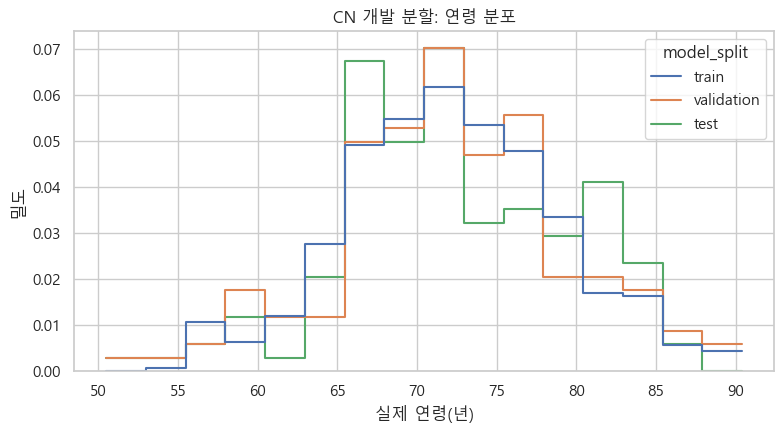

,점검 항목,결과,처리 및 해석
0,필수 변수 완전성,원본 특성의 비수치/결측 값 0개,필수 변수 완전 검사와 참가자별 최초 적격 검사만 분석에 포함
1,분석 코호트 ROI 완전성,"2,385명 모두 191개 ROI와 공변량 보유",추가 대치 없이 분석; 모델 파이프라인의 대치는 재현성 보호용
2,연령 점검,범위 49.0–97.4세; 40–100세 밖 0건,"비현실적 값 여부만 확인, 사전 정의 없는 연령 제거 없음"
3,성별·ICV 점검,성별 코드 외 값 0건; ICV 0 이하 0건,필수 변수 완전성 기준에서 제외; 분석에는 성별과 ICV 포함
4,참가자 중복 방지,"최초 적격 T1만 사용: 2,385명",한 사람의 여러 방문이 서로 다른 분할에 들어가는 누수 방지
5,ROI 통계적 극단값 탐지,MAD |z|>6 ROI가 5개 이상인 참가자 0명,영상 수준 QC 변수가 없어 자동 제거하지 않음; 실제 해부학적 편차 보존
6,영상 수준 QC 열,발견된 QC 유사 열 0개,motion/segmentation pass-fail 정보가 원자료에 없어 별도 M...
7,스캐너 조화,입력 ROI는 _combat 열,"ComBat 조화값 사용, 임상군 분석에서 scanner batch 민감도 분석 추가"
8,CN RID 분할 누수,중복 RID 0명,RID 단위 분할이므로 누수 없음
9,CN 분할 층화,연령 삼분위와 성별을 결합해 층화,훈련/검증/테스트의 연령·성별 불균형 완화


In [6]:
cn_df = analysis_df.loc[analysis_df["analysis_group"].eq("CN")].copy()
assert cn_df["RID"].is_unique, "CN 개발 코호트에 RID 중복이 있습니다."
assert len(cn_df) >= 100, "CN 표본이 모델 개발에 충분하지 않습니다."

# qcut 동률 문제를 피하기 위해 rank 후 삼분위를 만들고 성별과 결합해 층화합니다.
cn_df["_age_tertile"] = pd.qcut(
    cn_df["PHC_Age_T1"].rank(method="first"), q=3, labels=["young", "middle", "older"]
).astype(str)
cn_df["_split_stratum"] = cn_df["PHC_Sex"].astype(int).astype(str) + "_" + cn_df["_age_tertile"]

train_idx, temp_idx = train_test_split(
    cn_df.index, test_size=0.30, random_state=RANDOM_SEED, stratify=cn_df["_split_stratum"]
)
validation_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=RANDOM_SEED,
    stratify=cn_df.loc[temp_idx, "_split_stratum"],
)
cn_df["model_split"] = ""
cn_df.loc[train_idx, "model_split"] = "train"
cn_df.loc[validation_idx, "model_split"] = "validation"
cn_df.loc[test_idx, "model_split"] = "test"

analysis_df = analysis_df.merge(cn_df[["RID", "model_split"]], on="RID", how="left")
split_summary = (
    cn_df.groupby("model_split", observed=True)
    .agg(n=("RID", "size"), age_mean=("PHC_Age_T1", "mean"), age_sd=("PHC_Age_T1", "std"),
         female_share=("PHC_Sex", lambda values: float((values == 2).mean())))
    .reset_index().round(3)
)
split_summary.to_csv(OUTPUT_DIR / "cn_split_summary.csv", index=False, encoding="utf-8-sig")
display(split_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=cn_df, x="PHC_Age_T1", hue="model_split", bins=16, stat="density", common_norm=False,
             element="step", fill=False, ax=ax)
ax.set(title="CN 개발 분할: 연령 분포", xlabel="실제 연령(년)", ylabel="밀도")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_cn_split_age_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

# 분할 후 다시 RID 누수가 없는지 확인하고 전처리 감사표에 기록합니다.
split_rids = {
    split: set(cn_df.loc[cn_df["model_split"].eq(split), "RID"])
    for split in ["train", "validation", "test"]
}
split_overlap = sum([
    len(split_rids["train"] & split_rids["validation"]),
    len(split_rids["train"] & split_rids["test"]),
    len(split_rids["validation"] & split_rids["test"]),
])
assert split_overlap == 0, "CN 훈련/검증/테스트 사이에 RID 누수가 있습니다."
audit_rows.extend([
    {"점검 항목": "CN RID 분할 누수", "결과": f"중복 RID {split_overlap}명", "처리 및 해석": "RID 단위 분할이므로 누수 없음"},
    {"점검 항목": "CN 분할 층화", "결과": "연령 삼분위와 성별을 결합해 층화", "처리 및 해석": "훈련/검증/테스트의 연령·성별 불균형 완화"},
])
preprocessing_audit = pd.DataFrame(audit_rows)
preprocessing_audit.to_csv(OUTPUT_DIR / "preprocessing_audit.csv", index=False, encoding="utf-8-sig")
display(preprocessing_audit)

## 5. 후보 brain-age 모델 학습 및 선택

ROI는 서로 강하게 상관되어 있어 Ridge(L2 규제)가 안정적인 기본 모델이다. 동시에 Elastic Net도 후보로 비교한다. 각 후보의 하이퍼파라미터는 **CN 훈련 집합 내부의 5겹 교차검증**으로만 찾고, 후보 간 선택은 검증 CN의 MAE로 한다. 최종 테스트 CN은 이 단계에 전혀 사용하지 않는다.

In [7]:
train_df = cn_df.loc[cn_df["model_split"].eq("train")].copy()
validation_df = cn_df.loc[cn_df["model_split"].eq("validation")].copy()
test_df = cn_df.loc[cn_df["model_split"].eq("test")].copy()

X_train, y_train = train_df[FEATURE_COLUMNS], train_df["PHC_Age_T1"]
X_validation, y_validation = validation_df[FEATURE_COLUMNS], validation_df["PHC_Age_T1"]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df["PHC_Age_T1"]

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def make_pipeline(regressor):
    # 대치와 표준화는 반드시 파이프라인 안에 둬 CV fold 밖의 정보를 보지 않게 합니다.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("regressor", regressor),
    ])

candidate_specs = {
    "Ridge": (
        make_pipeline(Ridge()),
        {"regressor__alpha": np.logspace(-2, 5, 25)},
    ),
    "ElasticNet": (
        make_pipeline(ElasticNet(max_iter=50000, tol=1e-4, random_state=RANDOM_SEED)),
        {"regressor__alpha": np.logspace(-3, 1, 12), "regressor__l1_ratio": [0.05, 0.2, 0.5, 0.8]},
    ),
}

fitted_candidates = {}
selection_rows = []
for model_name, (pipeline, param_grid) in candidate_specs.items():
    search = GridSearchCV(
        pipeline, param_grid=param_grid, scoring="neg_mean_absolute_error", cv=cv,
        n_jobs=-1, refit=True, return_train_score=False,
    )
    # Windows의 loky 임시 파일 정리 메시지를 피하기 위해 스레드 기반 병렬 탐색을 사용합니다.
    with joblib.parallel_backend("threading"):
        search.fit(X_train, y_train)
    validation_prediction = search.predict(X_validation)
    fitted_candidates[model_name] = search
    selection_rows.append({
        "model": model_name,
        "cv_mae_years": -float(search.best_score_),
        "validation_mae_years": float(mean_absolute_error(y_validation, validation_prediction)),
        "validation_rmse_years": float(mean_squared_error(y_validation, validation_prediction) ** 0.5),
        "validation_r2": float(r2_score(y_validation, validation_prediction)),
        "best_parameters": json.dumps(search.best_params_, ensure_ascii=False),
    })

selection_table = pd.DataFrame(selection_rows).sort_values(["validation_mae_years", "cv_mae_years"]).reset_index(drop=True)
SELECTED_MODEL_NAME = selection_table.loc[0, "model"]
selected_search = fitted_candidates[SELECTED_MODEL_NAME]
selected_model = selected_search.best_estimator_
if SELECTED_MODEL_NAME == "ElasticNet":
    selected_regressor = selected_model.named_steps["regressor"]
    assert selected_regressor.n_iter_ < selected_regressor.max_iter, (
        "선택된 ElasticNet 모델이 수렴하지 않았습니다."
    )
selection_table["selected"] = selection_table["model"].eq(SELECTED_MODEL_NAME)
selection_table.to_csv(OUTPUT_DIR / "model_selection.csv", index=False, encoding="utf-8-sig")
display(selection_table.round(3))
print(f"선택 모델: {SELECTED_MODEL_NAME} | 파라미터: {selected_search.best_params_}")

,model,cv_mae_years,validation_mae_years,validation_rmse_years,validation_r2,best_parameters,selected
0,ElasticNet,3.777,3.926,5.060,0.507,"{""regressor__alpha"": 0.3511191734215131, ""regr...",True
1,Ridge,3.774,3.934,5.071,0.505,"{""regressor__alpha"": 237.13737056616552}",False


선택 모델: ElasticNet | 파라미터: {'regressor__alpha': np.float64(0.3511191734215131), 'regressor__l1_ratio': 0.05}


## 6. BAG 보정, 독립 성능 평가, 순열검정

raw BAG는 `예측 뇌 연령 - 실제 연령`이다. 뇌연령 모델은 실제 연령에 따라 과대·과소예측되는 경향이 있어, 검증 CN에서 `예측 연령 = a + b x 실제 연령`을 적합한 후 `보정 예측 연령 = (예측 연령 - a) / b`를 사용한다. 보정 계수는 고정한 뒤 최종 CN 테스트와 MCI/AD 모두에 똑같이 적용한다.

유의성은 두 관점으로 제시한다. (1) 독립 테스트의 MAE/RMSE/R2와 부트스트랩 95% 신뢰구간, (2) 훈련 연령을 500회 무작위로 섞어 만든 모델보다 관측 MAE가 좋은지의 단측 순열 p값이다. 이 p값은 예측 연관성의 우연 가능성을 평가할 뿐, 임상적 유용성을 보장하지는 않는다.

In [8]:
validation_prediction = selected_model.predict(X_validation)
# np.polyfit는 [기울기, 절편] 순서를 반환합니다.
calibration_slope_b, calibration_intercept_a = np.polyfit(y_validation.to_numpy(), validation_prediction, deg=1)
if abs(calibration_slope_b) < 1e-6:
    raise RuntimeError("검증 집합의 연령 편향 기울기가 0에 가까워 BAG 보정이 불안정합니다.")

all_prediction_raw = selected_model.predict(analysis_df[FEATURE_COLUMNS])
results = analysis_df[["analysis_group", "model_split", "PHC_Age_T1", "PHC_Sex", ICV_COLUMN, "PHC_ScannerBatchName"]].copy()
results = results.rename(columns={"PHC_Age_T1": "chronological_age", "PHC_Sex": "sex", ICV_COLUMN: "icv", "PHC_ScannerBatchName": "scanner_batch"})
results["predicted_brain_age_raw"] = all_prediction_raw
results["raw_BAG"] = results["predicted_brain_age_raw"] - results["chronological_age"]
results["predicted_brain_age_corrected"] = (results["predicted_brain_age_raw"] - calibration_intercept_a) / calibration_slope_b
results["corrected_BAG"] = results["predicted_brain_age_corrected"] - results["chronological_age"]

test_results = results.loc[results["model_split"].eq("test")].copy()

def metric_dict(y_true, y_pred):
    return {
        "MAE_years": float(mean_absolute_error(y_true, y_pred)),
        "RMSE_years": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2": float(r2_score(y_true, y_pred)),
    }

raw_test_metrics = metric_dict(test_results["chronological_age"], test_results["predicted_brain_age_raw"])
corrected_test_metrics = metric_dict(test_results["chronological_age"], test_results["predicted_brain_age_corrected"])
baseline_prediction = np.repeat(float(y_train.mean()), len(y_test))
baseline_test_metrics = metric_dict(y_test, baseline_prediction)

def bootstrap_metric_ci(y_true, y_pred, n_boot=2000):
    # 독립 테스트 참가자를 복원추출해 성능 불확실성을 계산합니다.
    values = {"MAE_years": [], "RMSE_years": [], "R2": []}
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    for _ in range(n_boot):
        sample = rng.integers(0, len(y_true), len(y_true))
        current = metric_dict(y_true[sample], y_pred[sample])
        for key, value in current.items():
            values[key].append(value)
    return {key: np.quantile(value, [0.025, 0.975]).tolist() for key, value in values.items()}

test_raw_prediction = test_results["predicted_brain_age_raw"].to_numpy()
bootstrap_ci = bootstrap_metric_ci(y_test.to_numpy(), test_raw_prediction)

# 순열검정은 선택된 모델 구조를 고정한 조건부 검정입니다.
permutation_maes = []
permutation_r2s = []
for _ in range(500):
    permuted_model = clone(selected_model)
    permuted_model.fit(X_train, rng.permutation(y_train.to_numpy()))
    permuted_prediction = permuted_model.predict(X_test)
    permutation_maes.append(mean_absolute_error(y_test, permuted_prediction))
    permutation_r2s.append(r2_score(y_test, permuted_prediction))
permutation_maes = np.asarray(permutation_maes)
permutation_r2s = np.asarray(permutation_r2s)
model_permutation_p = float((1 + np.sum(permutation_maes <= raw_test_metrics["MAE_years"])) / (len(permutation_maes) + 1))
model_permutation_r2_p = float((1 + np.sum(permutation_r2s >= raw_test_metrics["R2"])) / (len(permutation_r2s) + 1))

model_performance = pd.DataFrame([
    {"evaluation": "CN test raw prediction", **raw_test_metrics,
     "MAE_95CI_low": bootstrap_ci["MAE_years"][0], "MAE_95CI_high": bootstrap_ci["MAE_years"][1]},
    {"evaluation": "CN test bias-corrected prediction", **corrected_test_metrics,
     "MAE_95CI_low": np.nan, "MAE_95CI_high": np.nan},
    {"evaluation": "CN test train-mean baseline", **baseline_test_metrics,
     "MAE_95CI_low": np.nan, "MAE_95CI_high": np.nan},
])
model_performance.to_csv(OUTPUT_DIR / "cn_test_model_performance.csv", index=False, encoding="utf-8-sig")
calibration = {
    "equation": "predicted_age = a + b * chronological_age",
    "intercept_a": float(calibration_intercept_a),
    "slope_b": float(calibration_slope_b),
    "calibration_sample": "CN validation only",
    "raw_test_permutation_mae_p_value": model_permutation_p,
    "raw_test_permutation_r2_p_value": model_permutation_r2_p,
    "permutations": 500,
    "random_seed": RANDOM_SEED,
}
(OUTPUT_DIR / "bag_calibration.json").write_text(json.dumps(calibration, ensure_ascii=False, indent=2), encoding="utf-8")
joblib.dump(selected_model, OUTPUT_DIR / "brain_age_model.joblib")

# 저장본은 분석용 무작위 행 번호만 포함하고 ADNI 식별자/촬영일을 제외합니다.
saved_predictions = results.drop(columns=["scanner_batch"]).copy()
saved_predictions.insert(0, "analysis_row_id", rng.permutation(np.arange(1, len(saved_predictions) + 1)))
saved_predictions.to_csv(OUTPUT_DIR / "brain_age_predictions_deidentified.csv", index=False, encoding="utf-8-sig")

display(model_performance.round(3))
print(f"BAG 보정식: predicted_age = {calibration_intercept_a:.3f} + {calibration_slope_b:.3f} x age")
print(f"MAE 순열검정 p값: {model_permutation_p:.4g}")
print(f"R2 순열검정 p값: {model_permutation_r2_p:.4g}")

,evaluation,MAE_years,RMSE_years,R2,MAE_95CI_low,MAE_95CI_high
0,CN test raw prediction,4.173,5.296,0.445,3.663,4.706
1,CN test bias-corrected prediction,5.330,6.761,0.095,NaN,NaN
2,CN test train-mean baseline,5.671,7.109,-0.000,NaN,NaN


BAG 보정식: predicted_age = 39.721 + 0.457 x age
MAE 순열검정 p값: 0.001996
R2 순열검정 p값: 0.001996


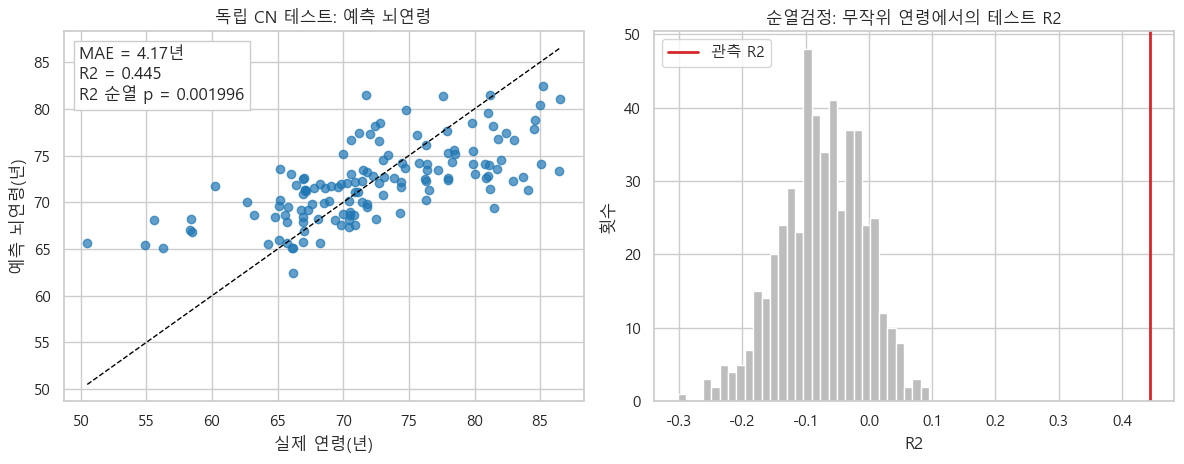

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(test_results["chronological_age"], test_results["predicted_brain_age_raw"], alpha=0.7, color="#1f77b4")
bounds = [
    min(test_results["chronological_age"].min(), test_results["predicted_brain_age_raw"].min()),
    max(test_results["chronological_age"].max(), test_results["predicted_brain_age_raw"].max()),
]
axes[0].plot(bounds, bounds, "--", color="black", linewidth=1)
axes[0].set(title="독립 CN 테스트: 예측 뇌연령", xlabel="실제 연령(년)", ylabel="예측 뇌연령(년)")
axes[0].text(
    0.03, 0.96,
    f"MAE = {raw_test_metrics['MAE_years']:.2f}년\nR2 = {raw_test_metrics['R2']:.3f}\nR2 순열 p = {model_permutation_r2_p:.4g}",
    transform=axes[0].transAxes, va="top", bbox={"facecolor": "white", "edgecolor": "0.8"},
)

axes[1].hist(permutation_r2s, bins=30, color="#bdbdbd", edgecolor="white")
axes[1].axvline(raw_test_metrics["R2"], color="#d62728", linewidth=2, label="관측 R2")
axes[1].set(title="순열검정: 무작위 연령에서의 테스트 R2", xlabel="R2", ylabel="횟수")
axes[1].legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_cn_test_prediction_and_permutation.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. 임상군 BAG 차이: 공변량 보정 ANCOVA

일차 분석은 독립 CN 테스트, MCI, AD를 비교하는 강건 표준오차(HC3) 선형모형이다.

`corrected_BAG ~ group + chronological_age + sex + ICV`

단순 평균차가 아니라 연령, 성별, 두개강내 용적(ICV)을 보정한 MCI와 AD의 CN 대비 차이를 추정한다. 두 계획 대비(MCI-CN, AD-CN)는 Holm 보정한다. ComBat 특성이 이미 조화되어 있지만, scanner batch를 추가한 민감도 분석도 함께 수행한다. 이는 임상군 차이가 모델의 예측력 또는 인과관계를 증명하는 검정이 아니라, 보정 BAG와 진단군의 연관성을 평가한다.

In [10]:
comparison = pd.concat(
    [
        results.loc[results["model_split"].eq("test")].assign(comparison_group="CN_test"),
        results.loc[results["analysis_group"].eq("MCI")].assign(comparison_group="MCI"),
        results.loc[results["analysis_group"].eq("AD")].assign(comparison_group="AD"),
    ],
    ignore_index=True,
)
comparison["comparison_group"] = pd.Categorical(comparison["comparison_group"], categories=["CN_test", "MCI", "AD"])
comparison["scanner_batch"] = comparison["scanner_batch"].fillna("Unknown").astype(str)

primary_formula = "corrected_BAG ~ C(comparison_group, Treatment(reference='CN_test')) + chronological_age + sex + icv"
primary_model = smf.ols(primary_formula, data=comparison).fit(cov_type="HC3")

def extract_group_contrasts(model, analysis_name):
    rows = []
    for group in ["MCI", "AD"]:
        term = next(name for name in model.params.index if f"T.{group}]" in name)
        interval = model.conf_int().loc[term]
        rows.append({
            "analysis": analysis_name,
            "contrast": f"{group} - CN_test",
            "estimate_years": float(model.params[term]),
            "CI95_low": float(interval.iloc[0]),
            "CI95_high": float(interval.iloc[1]),
            "p_value": float(model.pvalues[term]),
        })
    output = pd.DataFrame(rows)
    output["p_value_holm"] = multipletests(output["p_value"], method="holm")[1]
    output["significant_at_0_05_holm"] = output["p_value_holm"] < 0.05
    return output

primary_contrasts = extract_group_contrasts(primary_model, "Primary: age + sex + ICV")

# 표본 수가 10명 미만인 scanner batch는 Other로 합쳐 불안정한 더미 계수를 피합니다.
scanner_counts = comparison["scanner_batch"].value_counts()
comparison["scanner_group"] = comparison["scanner_batch"].where(comparison["scanner_batch"].map(scanner_counts).ge(10), "Other")
scanner_formula = primary_formula + " + C(scanner_group)"
scanner_model = smf.ols(scanner_formula, data=comparison).fit(cov_type="HC3")
scanner_contrasts = extract_group_contrasts(scanner_model, "Sensitivity: + scanner batch")

group_summary = (
    comparison.groupby("comparison_group", observed=True)
    .agg(n=("corrected_BAG", "size"), age_mean=("chronological_age", "mean"),
         female_share=("sex", lambda values: float((values == 2).mean())),
         corrected_BAG_mean=("corrected_BAG", "mean"), corrected_BAG_sd=("corrected_BAG", "std"))
    .reset_index().round(3)
)
clinical_inference = pd.concat([primary_contrasts, scanner_contrasts], ignore_index=True)
group_summary.to_csv(OUTPUT_DIR / "bag_group_summary.csv", index=False, encoding="utf-8-sig")
clinical_inference.to_csv(OUTPUT_DIR / "bag_group_inference_ancova.csv", index=False, encoding="utf-8-sig")

display(group_summary)
display(clinical_inference.round(4))

,comparison_group,n,age_mean,female_share,corrected_BAG_mean,corrected_BAG_sd
0,CN_test,137,72.319,0.577,-1.365,6.646
1,MCI,1088,73.073,0.423,4.804,9.110
2,AD,386,74.854,0.459,13.367,10.267


,analysis,contrast,estimate_years,CI95_low,CI95_high,p_value,p_value_holm,significant_at_0_05_holm
0,Primary: age + sex + ICV,MCI - CN_test,6.0935,4.8654,7.3216,0.0,0.0,True
1,Primary: age + sex + ICV,AD - CN_test,15.1315,13.6559,16.6070,0.0,0.0,True
2,Sensitivity: + scanner batch,MCI - CN_test,5.1381,3.9058,6.3705,0.0,0.0,True
3,Sensitivity: + scanner batch,AD - CN_test,13.4625,11.9784,14.9466,0.0,0.0,True


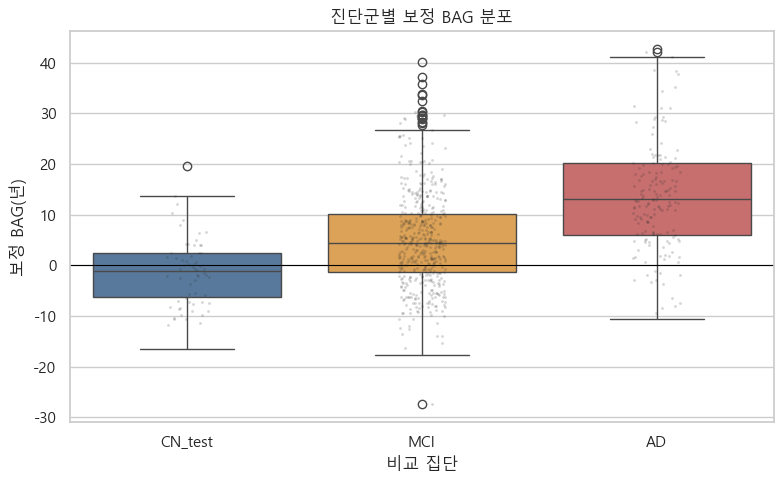

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=comparison, x="comparison_group", y="corrected_BAG", palette=["#4c78a8", "#f2a541", "#d65f5f"], ax=ax)
plot_sample = comparison.sample(min(len(comparison), 700), random_state=RANDOM_SEED)
sns.stripplot(data=plot_sample, x="comparison_group", y="corrected_BAG", color="#303030", alpha=0.2, size=2, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="진단군별 보정 BAG 분포", xlabel="비교 집단", ylabel="보정 BAG(년)")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_corrected_bag_by_group.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. ROI 수준 노화 부담 요약

각 ROI에 대해 CN 훈련 집합에서 `ROI ~ age + sex + ICV` 규범모형을 만들고, 잔차를 훈련 잔차 표준편차로 나눈 Z-score를 계산한다. 피질 두께·회색질/피질하 용적은 값이 낮을수록, 뇌실/CSF는 값이 높을수록 노화 부담이 크다고 정의해 부호를 통일한다. 이 단계는 뇌연령 모델의 feature importance가 아니라 **또래 CN 기대치 대비 구조 편차**를 보여준다.

개인정보 보호를 위해 개인별 ROI 점수는 저장하지 않고, 집단 평균 요약과 열지도만 저장한다.

,analysis_group,roi,parcel,hemisphere,roi_role,mean_aging_burden_z,sd_aging_burden_z,n
0,AD,X3rd.Ventricle_combat,X3rd.Ventricle,Global,ventricle_or_csf,0.562082,1.141067,386
1,CN,X3rd.Ventricle_combat,X3rd.Ventricle,Global,ventricle_or_csf,0.013301,0.998652,911
2,MCI,X3rd.Ventricle_combat,X3rd.Ventricle,Global,ventricle_or_csf,0.221406,1.090623,1088
3,AD,X4th.Ventricle_combat,X4th.Ventricle,Global,ventricle_or_csf,0.088568,1.079352,386
4,CN,X4th.Ventricle_combat,X4th.Ventricle,Global,ventricle_or_csf,0.018254,0.999292,911


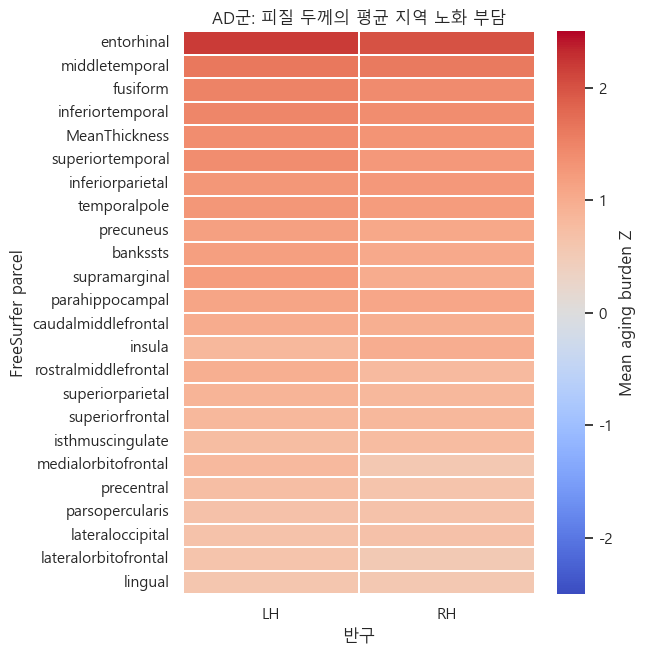

In [12]:
def roi_role(column):
    if column.startswith(("lh_", "rh_")) and "_thickness_" in column:
        return "cortical_thickness"
    if column.startswith(("lh_", "rh_")) and "_volume_" in column:
        return "cortical_volume"
    if "Ventricle" in column or column in {"CSF_combat", "X3rd.Ventricle_combat", "X4th.Ventricle_combat"}:
        return "ventricle_or_csf"
    if column.startswith(("Left.", "Right.")):
        return "subcortical_volume"
    return "global_or_other"

def roi_label(column):
    if column.startswith(("lh_", "rh_")):
        hemisphere = "LH" if column.startswith("lh_") else "RH"
        parcel = column[3:].replace("_thickness_combat", "").replace("_volume_combat", "")
    elif column.startswith(("Left.", "Right.")):
        hemisphere = "LH" if column.startswith("Left.") else "RH"
        parcel = column.split(".", 1)[1].removesuffix("_combat")
    else:
        hemisphere = "Global"
        parcel = column.removesuffix("_combat")
    return hemisphere, parcel

normative_train = analysis_df.loc[
    analysis_df["analysis_group"].eq("CN") & analysis_df["model_split"].eq("train")
].copy()
covariates = ["PHC_Age_T1", "PHC_Sex", ICV_COLUMN]
norm_pipeline = lambda: Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0)),
])

burden_records = []
for roi in ROI_COLUMNS:
    model = norm_pipeline()
    model.fit(normative_train[covariates], normative_train[roi])
    expected = model.predict(analysis_df[covariates])
    train_resid = normative_train[roi].to_numpy() - model.predict(normative_train[covariates])
    residual_sd = float(np.std(train_resid, ddof=1))
    if not np.isfinite(residual_sd) or residual_sd <= 1e-10:
        continue
    z_score = (analysis_df[roi].to_numpy() - expected) / residual_sd
    role = roi_role(roi)
    burden = z_score if role == "ventricle_or_csf" else -z_score
    hemisphere, parcel = roi_label(roi)
    group_values = pd.DataFrame({"group": analysis_df["analysis_group"], "burden": burden})
    for group, values in group_values.groupby("group", observed=True):
        burden_records.append({
            "analysis_group": group, "roi": roi, "parcel": parcel, "hemisphere": hemisphere,
            "roi_role": role, "mean_aging_burden_z": float(values["burden"].mean()),
            "sd_aging_burden_z": float(values["burden"].std()), "n": len(values),
        })

regional_summary = pd.DataFrame(burden_records)
regional_summary.to_csv(OUTPUT_DIR / "regional_aging_burden_group_summary.csv", index=False, encoding="utf-8-sig")

cortical_ad = regional_summary.loc[
    regional_summary["analysis_group"].eq("AD") & regional_summary["roi_role"].eq("cortical_thickness")
].copy()
top_parcels = cortical_ad.groupby("parcel", observed=True)["mean_aging_burden_z"].mean().abs().nlargest(24).index
heat = (
    cortical_ad.loc[cortical_ad["parcel"].isin(top_parcels)]
    .pivot(index="parcel", columns="hemisphere", values="mean_aging_burden_z")
    .reindex(top_parcels)
)
display(regional_summary.head())

fig, ax = plt.subplots(figsize=(6.5, max(6, len(heat) * 0.28)))
sns.heatmap(heat, cmap="coolwarm", center=0, vmin=-2.5, vmax=2.5, linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Mean aging burden Z"}, ax=ax)
ax.set(title="AD군: 피질 두께의 평균 지역 노화 부담", xlabel="반구", ylabel="FreeSurfer parcel")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_ad_cortical_thickness_regional_burden.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. MCI의 24개월 AD 전환 탐색

일차 brain-age 모델을 다시 학습하지 않고, CN 기반으로 고정한 모델과 BAG 보정 계수를 사용한다. 따라서 MCI/AD 임상 정보가 뇌연령 모델 학습에 누수되지 않는다.

In [13]:
# 이 노트북은 결과 폴더에서 실행하도록 설계했습니다.
from pathlib import Path
from datetime import datetime
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_SEED = 20260814

# Resolve the project and authorized ADNI source without a user-specific path.
import os

def resolve_project_and_source():
    project_override = os.environ.get("ADNI_PROJECT_ROOT")
    project_candidates = [Path(project_override).expanduser()] if project_override else []
    working_directory = Path.cwd().resolve()
    project_candidates.extend([working_directory, *working_directory.parents])
    project_dir = next(
        (candidate for candidate in project_candidates
         if (candidate / "ADNI_Brain_Age_Gap_V3_Integrated.ipynb").is_file()),
        None,
    )
    if project_dir is None:
        raise FileNotFoundError(
            "V3 project folder was not found. Start Jupyter from this project folder or set ADNI_PROJECT_ROOT."
        )

    data_candidates = []
    data_override = os.environ.get("ADNI_DATA_ROOT")
    if data_override:
        data_candidates.append(Path(data_override).expanduser())
    data_candidates.extend([project_dir / "ADNI_data", project_dir.parent / "ADNI_data"])
    source_root = next(
        (candidate for candidate in data_candidates
         if (candidate / "ADSP_PHC" / "ADSP_PHC_T1_FS_22Jan2026.csv").is_file()),
        None,
    )
    if source_root is None:
        raise FileNotFoundError(
            "Authorized ADNI_data was not found. Place ADNI_data beside this project, inside this project, "
            "or set ADNI_DATA_ROOT to its folder."
        )
    return project_dir, source_root

PROJECT_DIR, SOURCE_ROOT = resolve_project_and_source()
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

T1_FILE = SOURCE_ROOT / "ADSP_PHC" / "ADSP_PHC_T1_FS_22Jan2026.csv"
DXSUM_FILE = SOURCE_ROOT / "Assessments" / "DXSUM_22Jan2026.csv"
MODEL_FILE = OUTPUT_DIR / "brain_age_model.joblib"
CALIBRATION_FILE = OUTPUT_DIR / "bag_calibration.json"
for path in [T1_FILE, DXSUM_FILE, MODEL_FILE, CALIBRATION_FILE]:
    assert path.exists(), f"필수 파일을 찾을 수 없습니다: {path}"

sns.set_theme(style="whitegrid", context="notebook", rc={"font.family": "Malgun Gothic", "axes.unicode_minus": False})
print(f"결과 폴더: {PROJECT_DIR}")
print(f"실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

결과 폴더: C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3.13.9_Base
실행 시각: 2026-08-20 14:26:16


### 9.1. 일차 분석과 같은 MCI baseline MRI 코호트 복원

원본 T1 FreeSurfer 표에서 필수 메타데이터와 192개 ComBat 특성이 모두 있는 검사를 고른 뒤, RID별 가장 이른 적격 T1 검사 1개만 선택한다. 이 규칙은 일차 분석과 동일하다. RID와 촬영일은 DXSUM 연결에만 메모리 안에서 사용하고, 결과 파일에는 저장하지 않는다.

In [14]:
raw = pd.read_csv(T1_FILE, low_memory=False)
combat_columns = [column for column in raw.columns if column.endswith("_combat")]
ICV_COLUMN = "EstimatedTotalIntraCranialVol_combat"
ROI_COLUMNS = [column for column in combat_columns if column != ICV_COLUMN]
DEFAULT_FEATURE_COLUMNS = [*ROI_COLUMNS, "PHC_Sex", ICV_COLUMN]

work = raw.copy()
work["_scan_date"] = pd.to_datetime(work["PHC_SCANDATE"], errors="coerce")
work["diagnosis"] = pd.to_numeric(work["PHC_Diagnosis"], errors="coerce").map({1: "CN", 2: "MCI", 3: "AD"})
required_columns = ["RID", "_scan_date", "PHC_Age_T1", "PHC_Sex", "diagnosis", *DEFAULT_FEATURE_COLUMNS]
eligible = work.dropna(subset=required_columns).sort_values(["RID", "_scan_date"]).groupby("RID", as_index=False).first()
mci_baseline = eligible.loc[eligible["diagnosis"].eq("MCI")].copy()

# 저장된 모델을 그대로 사용해 일차 분석의 MCI BAG를 재현합니다.
brain_age_model = joblib.load(MODEL_FILE)
feature_columns = list(getattr(brain_age_model, "feature_names_in_", DEFAULT_FEATURE_COLUMNS))
calibration = json.loads(CALIBRATION_FILE.read_text(encoding="utf-8"))
raw_prediction = brain_age_model.predict(mci_baseline[feature_columns])
mci_baseline["corrected_BAG"] = (
    (raw_prediction - calibration["intercept_a"]) / calibration["slope_b"] - mci_baseline["PHC_Age_T1"]
)
mci_baseline = mci_baseline[["RID", "_scan_date", "PHC_Age_T1", "PHC_Sex", ICV_COLUMN, "corrected_BAG"]].copy()
print(f"MCI baseline MRI: {len(mci_baseline):,}명")

MCI baseline MRI: 1,088명


### 9.2. 24개월 AD 전환 결과 정의

MRI 후 30일을 넘긴 DXSUM 기록만 미래 관찰로 사용한다. `DXAD == 1`의 가장 이른 날짜가 MRI 후 730일 이내면 사건으로 정의한다. 사건이 없으면 적어도 730일의 DXSUM 관찰이 있어야 비전환자로 포함한다. 이로써 결과가 전혀 관찰되지 않은 사람을 비전환자로 오분류하지 않는다.

In [15]:
HORIZON_DAYS = 730
FUTURE_BUFFER_DAYS = 30

dxsum = pd.read_csv(DXSUM_FILE, low_memory=False)
dxsum["_exam_date"] = pd.to_datetime(dxsum["EXAMDATE"], errors="coerce")
dxsum = dxsum.dropna(subset=["RID", "_exam_date"]).copy()
dxsum["_ad_event"] = pd.to_numeric(dxsum["DXAD"], errors="coerce").eq(1)

future_visits = mci_baseline[["RID", "_scan_date"]].merge(
    dxsum[["RID", "_exam_date", "_ad_event"]], on="RID", how="left"
)
future_visits["followup_days"] = (future_visits["_exam_date"] - future_visits["_scan_date"]).dt.days
future_visits = future_visits.loc[future_visits["followup_days"].gt(FUTURE_BUFFER_DAYS)].copy()

first_ad = future_visits.loc[future_visits["_ad_event"]].groupby("RID")["followup_days"].min().rename("first_ad_days")
last_followup = future_visits.groupby("RID")["followup_days"].max().rename("last_followup_days")
conversion = mci_baseline.merge(first_ad, on="RID", how="left").merge(last_followup, on="RID", how="left")
conversion["converted_to_ad_24m"] = conversion["first_ad_days"].le(HORIZON_DAYS).astype(int)
conversion["eligible_24m_outcome"] = (
    conversion["converted_to_ad_24m"].eq(1) | conversion["last_followup_days"].ge(HORIZON_DAYS)
)
conversion_study = conversion.loc[conversion["eligible_24m_outcome"]].copy()
conversion_study["age"] = conversion_study["PHC_Age_T1"]
conversion_study["sex"] = conversion_study["PHC_Sex"]
conversion_study["icv"] = conversion_study[ICV_COLUMN]

conversion_cohort_summary = pd.DataFrame([
    {"stage": "MCI baseline MRI", "n": len(mci_baseline)},
    {"stage": "MCI with any future DXSUM after 30 days", "n": int(future_visits["RID"].nunique())},
    {"stage": "Eligible 24-month outcome cohort", "n": len(conversion_study)},
    {"stage": "AD conversions within 24 months", "n": int(conversion_study["converted_to_ad_24m"].sum())},
])
conversion_cohort_summary.to_csv(OUTPUT_DIR / "mci_ad_conversion_24m_cohort_summary.csv", index=False, encoding="utf-8-sig")
display(conversion_cohort_summary)

,stage,n
0,MCI baseline MRI,1088
1,MCI with any future DXSUM after 30 days,993
2,Eligible 24-month outcome cohort,815
3,AD conversions within 24 months,108


### 9.3. 공변량 보정 로지스틱 회귀

일차 공변량은 baseline BAG, 실제 연령, 성별, ICV다. BAG의 odds ratio는 BAG 1년 증가당 24개월 내 AD 전환 odds 비율이다. HC3 강건 표준오차를 사용하며, 95% 신뢰구간과 p값을 함께 보고한다.

In [16]:
conversion_model = smf.logit(
    "converted_to_ad_24m ~ corrected_BAG + age + sex + icv", data=conversion_study
).fit(disp=False, cov_type="HC3")

bag_term = "corrected_BAG"
bag_ci_log_odds = conversion_model.conf_int().loc[bag_term]
bag_or = float(np.exp(conversion_model.params[bag_term]))
bag_ci_or = np.exp(bag_ci_log_odds)
conversion_inference = pd.DataFrame([{
    "outcome": "AD conversion within 24 months",
    "predictor": "Corrected BAG (per +1 year)",
    "n": len(conversion_study),
    "events": int(conversion_study["converted_to_ad_24m"].sum()),
    "event_rate": float(conversion_study["converted_to_ad_24m"].mean()),
    "odds_ratio": bag_or,
    "OR_95CI_low": float(bag_ci_or.iloc[0]),
    "OR_95CI_high": float(bag_ci_or.iloc[1]),
    "p_value": float(conversion_model.pvalues[bag_term]),
    "covariates": "age + sex + ICV; HC3 robust SE",
}])
conversion_inference.to_csv(OUTPUT_DIR / "mci_ad_conversion_24m_inference.csv", index=False, encoding="utf-8-sig")
display(conversion_inference.round(4))

,outcome,predictor,n,events,event_rate,odds_ratio,OR_95CI_low,OR_95CI_high,p_value,covariates
0,AD conversion within 24 months,Corrected BAG (per +1 year),815,108,0.1325,1.1635,1.1285,1.1997,0.0,age + sex + ICV; HC3 robust SE


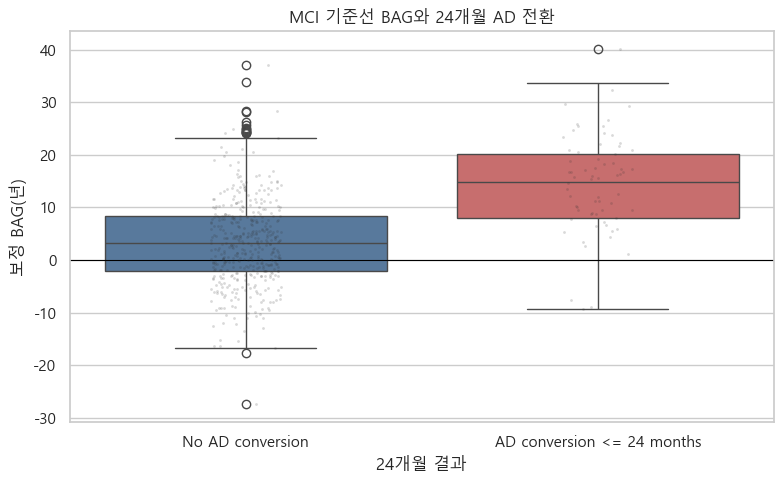

In [17]:
# 이 그림은 개별 ID 없이 전환 여부별 BAG 분포만 보여 줍니다.
plot_data = conversion_study[["converted_to_ad_24m", "corrected_BAG"]].copy()
plot_data["conversion_status"] = plot_data["converted_to_ad_24m"].map({0: "No AD conversion", 1: "AD conversion <= 24 months"})
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=plot_data, x="conversion_status", y="corrected_BAG", palette=["#4c78a8", "#d65f5f"], ax=ax)
sns.stripplot(data=plot_data.sample(min(len(plot_data), 500), random_state=RANDOM_SEED),
              x="conversion_status", y="corrected_BAG", color="#303030", alpha=0.18, size=2, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="MCI 기준선 BAG와 24개월 AD 전환", xlabel="24개월 결과", ylabel="보정 BAG(년)")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_mci_ad_conversion_24m_bag.png", dpi=180, bbox_inches="tight")
plt.show()

### 9.4. 결과 저장 및 해석

개인별 RID, PTID, 촬영일, 방문일은 저장하지 않는다. 전환 분석은 MCI 코호트의 선택, DXSUM 진단 기록의 완결성, 추적 일정, 미측정 교란에 영향을 받을 수 있다. 따라서 외부 코호트 검증과 사전 등록된 종단 분석 계획 없이 예측 도구의 임상 성능으로 해석하면 안 된다.

In [18]:
significance = "통계적으로 유의" if float(conversion_inference.loc[0, "p_value"]) < 0.05 else "통계적으로 유의하지 않음"
summary_lines = [
    "# MCI 24개월 AD 전환 탐색 분석", "",
    f"생성 시각: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", "",
    "## 분석 정의", "",
    "- 기준 시점: 참가자별 최초 적격 T1 MRI에서 PHC 진단이 MCI인 경우",
    "- 사건: MRI 후 30일 초과 시점의 DXSUM에서 DXAD=1이 처음 기록되고, 그 날짜가 730일 이내인 경우",
    "- 비사건 포함: 최소 730일의 DXSUM 추적이 있는 경우", "",
    "## 결과", "",
    f"- MCI 기준선 MRI: {len(mci_baseline):,}명",
    f"- 24개월 결과 적격 코호트: {len(conversion_study):,}명",
    f"- 24개월 AD 전환: {int(conversion_study['converted_to_ad_24m'].sum()):,}건 ({conversion_study['converted_to_ad_24m'].mean():.1%})",
    f"- BAG 1년 증가당 AD 전환 odds ratio: {bag_or:.3f} (95% CI {bag_ci_or.iloc[0]:.3f}-{bag_ci_or.iloc[1]:.3f}), p={conversion_model.pvalues[bag_term]:.4g}",
    f"- 연령, 성별, ICV 보정 후 BAG와 24개월 AD 전환의 연관성: **{significance}**", "",
    "## 주의", "",
    "이 결과는 ADNI 관찰자료에서 나온 탐색적 연관성이다. 개인별 전환 위험을 확정하거나 인과관계를 증명하지 않는다.",
]
summary_text = chr(10).join(summary_lines) + chr(10)
(PROJECT_DIR / "MCI_LONGITUDINAL_SUMMARY_KO.md").write_text(summary_text, encoding="utf-8")

extension_manifest = pd.DataFrame([
    {"file": "mci_ad_conversion_24m_cohort_summary.csv", "description": "식별자 없는 코호트 흐름"},
    {"file": "mci_ad_conversion_24m_inference.csv", "description": "보정 로지스틱 회귀 결과"},
    {"file": "figures/05_mci_ad_conversion_24m_bag.png", "description": "식별자 없는 BAG 분포 그림"},
    {"file": "MCI_LONGITUDINAL_SUMMARY_KO.md", "description": "한국어 결과 요약"},
])
extension_manifest.to_csv(OUTPUT_DIR / "mci_longitudinal_artifact_manifest.csv", index=False, encoding="utf-8-sig")
print(summary_text)

# MCI 24개월 AD 전환 탐색 분석

생성 시각: 2026-08-20 14:26:19

## 분석 정의

- 기준 시점: 참가자별 최초 적격 T1 MRI에서 PHC 진단이 MCI인 경우
- 사건: MRI 후 30일 초과 시점의 DXSUM에서 DXAD=1이 처음 기록되고, 그 날짜가 730일 이내인 경우
- 비사건 포함: 최소 730일의 DXSUM 추적이 있는 경우

## 결과

- MCI 기준선 MRI: 1,088명
- 24개월 결과 적격 코호트: 815명
- 24개월 AD 전환: 108건 (13.3%)
- BAG 1년 증가당 AD 전환 odds ratio: 1.164 (95% CI 1.128-1.200), p=3.115e-22
- 연령, 성별, ICV 보정 후 BAG와 24개월 AD 전환의 연관성: **통계적으로 유의**

## 주의

이 결과는 ADNI 관찰자료에서 나온 탐색적 연관성이다. 개인별 전환 위험을 확정하거나 인과관계를 증명하지 않는다.



## 10. BAG-연관 피질 노화의 뇌 표면 시각화

이 지도는 보정 BAG가 증가할수록 어떤 Desikan-Killiany 피질 두께 parcel에서 연령·성별·ICV를 고려한 추가적 얇아짐 부담이 큰지 보여 준다.

각 parcel은 CN 훈련 집단에서 실제 연령, 성별, ICV로 규준 모델을 만든 뒤, 독립 임상 비교 코호트(CN 테스트, MCI, AD)에서 보정 BAG와의 연관성을 HC3 강건 표준오차로 추정한다. 빨간색이 진할수록 BAG가 1 표준편차 높을 때 더 큰 피질 얇아짐 부담과 연관된다. 이는 표준 atlas 수준의 집단 결과이며 개인 MRI 판독이나 voxel 수준 병변 지도는 아니다.

같은 ROI가 brain-age 모델의 입력에도 포함되므로, 이 그림은 BAG를 구성하는 모델-연관 지역 지도이다. 특정 parcel이 BAG를 원인적으로 만든다는 독립 검증으로 해석하지 않는다.

In [19]:
# fsaverage5 표면과 FreeSurfer aparc annotation을 내려받아 ROI parcel을 표면 정점에 연결합니다.
from urllib.request import urlretrieve

import nibabel as nib
from matplotlib import cm, colors
from nilearn import datasets, plotting

# nilearn import 뒤에도 한글 그림 레이블이 깨지지 않도록 글꼴을 다시 명시 등록합니다.
korean_font_path = Path(r"C:\Windows\Fonts\NotoSansKR-Regular.ttf")
if korean_font_path.exists():
    font_manager.fontManager.addfont(str(korean_font_path))
    KOREAN_FONT = font_manager.FontProperties(fname=str(korean_font_path))
else:
    # The map remains usable on Windows installations without this optional font.
    KOREAN_FONT = font_manager.FontProperties(family="Malgun Gothic")
plt.rcParams["font.family"] = KOREAN_FONT.get_name()
plt.rcParams["axes.unicode_minus"] = False

SURFACE_ASSET_DIR = PROJECT_DIR / "assets" / "fsaverage5"
SURFACE_ASSET_DIR.mkdir(parents=True, exist_ok=True)
ANNOTATION_URLS = {
    "left": "https://www.freesurfer.net/pub/dist/freesurfer/tutorial_versions_centos6/freesurfer/subjects/fsaverage5/label/lh.aparc.annot",
    "right": "https://www.freesurfer.net/pub/dist/freesurfer/tutorial_versions_centos6/freesurfer/subjects/fsaverage5/label/rh.aparc.annot",
}
annotation_paths = {}
for hemisphere, url in ANNOTATION_URLS.items():
    path = SURFACE_ASSET_DIR / f"{hemisphere}.aparc.annot"
    if not path.exists():
        urlretrieve(url, path)
    annotation_paths[hemisphere] = path

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5", data_dir=str(SURFACE_ASSET_DIR))
print(f"fsaverage5 표면 자산 위치: {SURFACE_ASSET_DIR}")

fsaverage5 표면 자산 위치: C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3.13.9_Base\assets\fsaverage5


In [20]:
# 각 피질 두께 parcel에서 BAG와 비교 가능한 표준화 연관성을 추정합니다.
CORTICAL_THICKNESS_ROIS = [
    roi for roi in ROI_COLUMNS
    if roi.startswith(("lh_", "rh_")) and "_thickness_" in roi and "MeanThickness" not in roi
]
map_cohort = analysis_df.loc[
    (analysis_df["analysis_group"].isin(["MCI", "AD"]))
    | (analysis_df["analysis_group"].eq("CN") & analysis_df["model_split"].eq("test"))
].copy()
map_cohort["corrected_BAG"] = results.loc[map_cohort.index, "corrected_BAG"].to_numpy()

regional_association_records = []
for roi in CORTICAL_THICKNESS_ROIS:
    normative_model = norm_pipeline()
    normative_model.fit(normative_train[covariates], normative_train[roi])
    expected_value = normative_model.predict(map_cohort[covariates])
    normative_residual = normative_train[roi].to_numpy() - normative_model.predict(normative_train[covariates])
    normative_sd = float(np.std(normative_residual, ddof=1))
    if not np.isfinite(normative_sd) or normative_sd <= 1e-10:
        continue

    parcel_frame = map_cohort[["corrected_BAG", "PHC_Age_T1", "PHC_Sex", ICV_COLUMN]].copy()
    # 양의 부담은 규준 공변량 보정 뒤 기대치보다 피질이 더 얇다는 뜻입니다.
    parcel_frame["aging_burden_z"] = -(map_cohort[roi].to_numpy() - expected_value) / normative_sd
    for source, target in [("corrected_BAG", "bag_z"), ("PHC_Age_T1", "age_z"), (ICV_COLUMN, "icv_z")]:
        scale = float(parcel_frame[source].std(ddof=1))
        if not np.isfinite(scale) or scale <= 1e-10:
            raise RuntimeError(f"피질 연관성 분석에서 {source}를 표준화할 수 없습니다.")
        parcel_frame[target] = (parcel_frame[source] - parcel_frame[source].mean()) / scale

    fit = smf.ols("aging_burden_z ~ bag_z + age_z + PHC_Sex + icv_z", data=parcel_frame).fit(cov_type="HC3")
    hemisphere, parcel = roi_label(roi)
    interval = fit.conf_int().loc["bag_z"]
    regional_association_records.append({
        "roi": roi,
        "parcel": parcel,
        "hemisphere": hemisphere,
        "n": int(len(parcel_frame)),
        "bag_beta_per_1SD": float(fit.params["bag_z"]),
        "CI95_low": float(interval.iloc[0]),
        "CI95_high": float(interval.iloc[1]),
        "p_value": float(fit.pvalues["bag_z"]),
    })

bag_surface_stats = pd.DataFrame(regional_association_records)
bag_surface_stats["p_value_fdr_bh"] = multipletests(bag_surface_stats["p_value"], method="fdr_bh")[1]
bag_surface_stats["fdr_significant_0_05"] = bag_surface_stats["p_value_fdr_bh"] < 0.05
bag_surface_stats["surface_aging_value"] = bag_surface_stats["bag_beta_per_1SD"].clip(lower=0)
bag_surface_stats.to_csv(OUTPUT_DIR / "bag_cortical_surface_association.csv", index=False, encoding="utf-8-sig")

top_surface_parcels = bag_surface_stats.sort_values("bag_beta_per_1SD", ascending=False).head(20)
display(top_surface_parcels.round(4))
print(
    f"검정한 피질 parcel: {len(bag_surface_stats)}개 | "
    f"FDR 보정 후 양의 BAG 연관성: "
    f"{int((bag_surface_stats['fdr_significant_0_05'] & (bag_surface_stats['bag_beta_per_1SD'] > 0)).sum())}개"
)

,roi,parcel,hemisphere,n,bag_beta_per_1SD,CI95_low,CI95_high,p_value,p_value_fdr_bh,fdr_significant_0_05,surface_aging_value
15,lh_middletemporal_thickness_combat,middletemporal,LH,1611,0.9509,0.8859,1.0160,0.0,0.0,True,0.9509
49,rh_middletemporal_thickness_combat,middletemporal,RH,1611,0.9330,0.8695,0.9964,0.0,0.0,True,0.9330
41,rh_inferiorparietal_thickness_combat,inferiorparietal,RH,1611,0.8756,0.8194,0.9318,0.0,0.0,True,0.8756
7,lh_inferiorparietal_thickness_combat,inferiorparietal,LH,1611,0.8556,0.7934,0.9178,0.0,0.0,True,0.8556
30,lh_superiortemporal_thickness_combat,superiortemporal,LH,1611,0.8476,0.7941,0.9011,0.0,0.0,True,0.8476
64,rh_superiortemporal_thickness_combat,superiortemporal,RH,1611,0.8401,0.7868,0.8934,0.0,0.0,True,0.8401
31,lh_supramarginal_thickness_combat,supramarginal,LH,1611,0.8193,0.7644,0.8742,0.0,0.0,True,0.8193
40,rh_fusiform_thickness_combat,fusiform,RH,1611,0.7926,0.7323,0.8530,0.0,0.0,True,0.7926
34,rh_bankssts_thickness_combat,bankssts,RH,1611,0.7863,0.7275,0.8451,0.0,0.0,True,0.7863
4,lh_entorhinal_thickness_combat,entorhinal,LH,1611,0.7848,0.7125,0.8571,0.0,0.0,True,0.7848


검정한 피질 parcel: 68개 | FDR 보정 후 양의 BAG 연관성: 65개


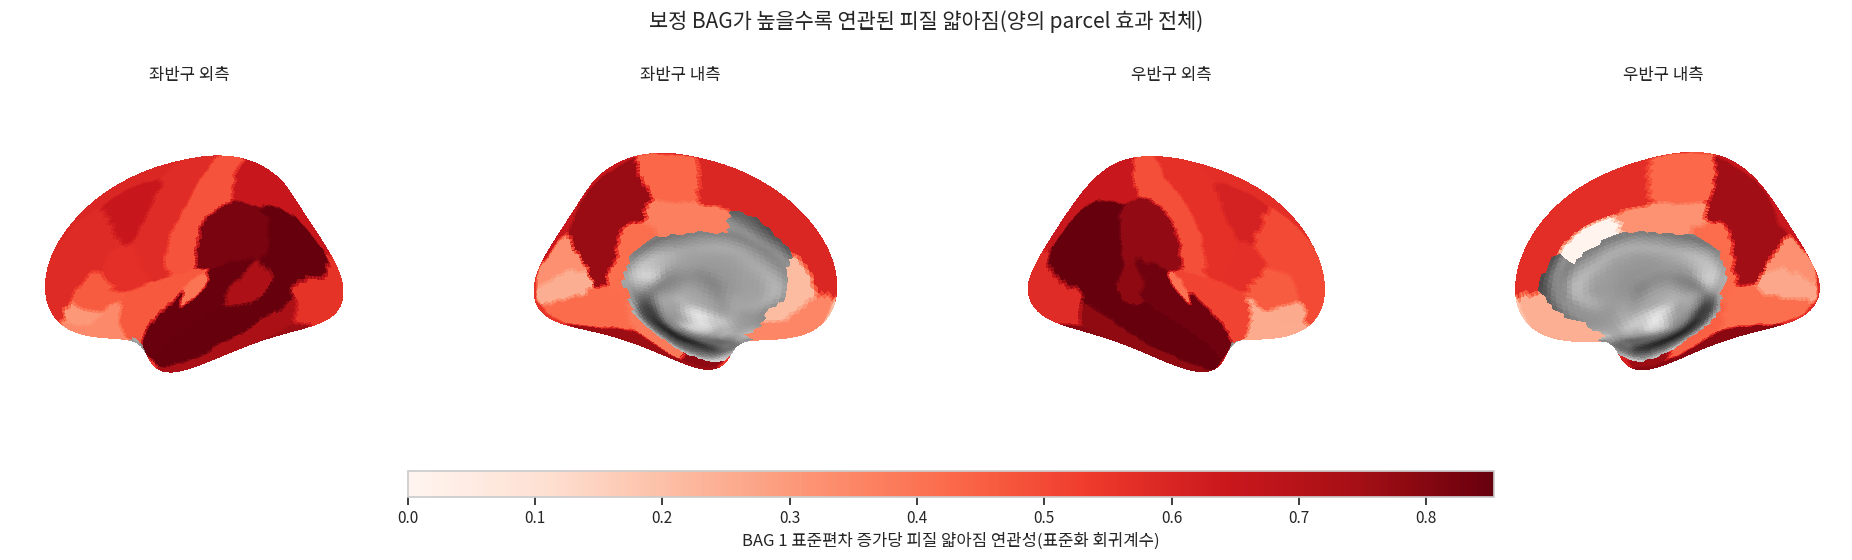

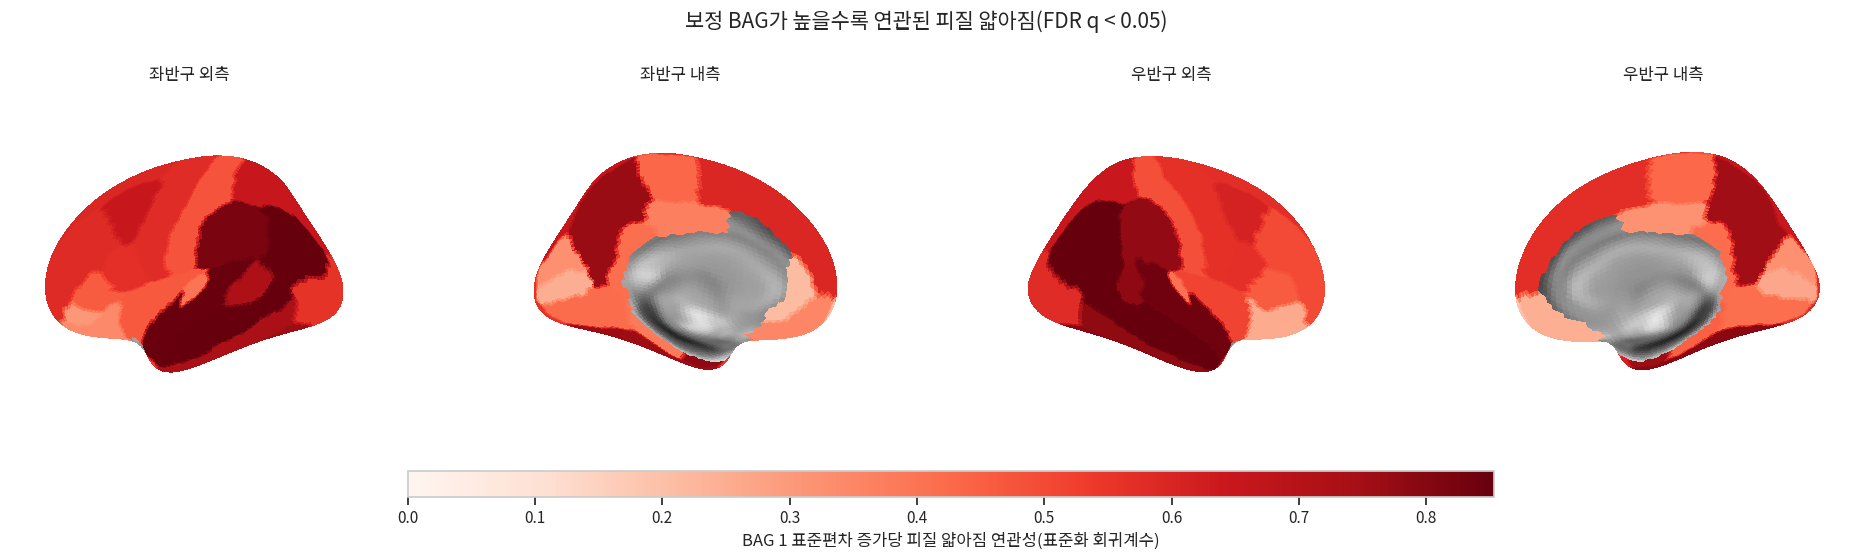

정적 뇌 표면 지도 저장: 06_bag_associated_cortical_aging_surface.png, 07_bag_associated_cortical_aging_surface_fdr.png


In [21]:
# parcel 효과를 fsaverage5 정점으로 변환해 자연스러운 표면 음영과 함께 정적 지도를 그립니다.
def annotation_to_surface_values(annotation_path, hemisphere, only_fdr_significant=False):
    labels, _, names = nib.freesurfer.read_annot(str(annotation_path))
    names = [name.decode("utf-8") for name in names]
    rows = bag_surface_stats.loc[bag_surface_stats["hemisphere"].eq(hemisphere)].copy()
    if only_fdr_significant:
        rows = rows.loc[rows["fdr_significant_0_05"] & rows["bag_beta_per_1SD"].gt(0)]
    else:
        rows = rows.loc[rows["bag_beta_per_1SD"].gt(0)]
    value_by_parcel = rows.set_index("parcel")["surface_aging_value"].to_dict()
    values = np.full(labels.shape, np.nan, dtype=float)
    for label_index, parcel_name in enumerate(names):
        if parcel_name in value_by_parcel:
            values[labels == label_index] = value_by_parcel[parcel_name]
    return values

left_all = annotation_to_surface_values(annotation_paths["left"], "LH")
right_all = annotation_to_surface_values(annotation_paths["right"], "RH")
left_fdr = annotation_to_surface_values(annotation_paths["left"], "LH", only_fdr_significant=True)
right_fdr = annotation_to_surface_values(annotation_paths["right"], "RH", only_fdr_significant=True)
assert len(left_all) == len(nib.load(fsaverage.infl_left).darrays[0].data)
assert len(right_all) == len(nib.load(fsaverage.infl_right).darrays[0].data)

positive_values = bag_surface_stats.loc[bag_surface_stats["surface_aging_value"].gt(0), "surface_aging_value"]
surface_vmax = float(np.quantile(positive_values, 0.95)) if len(positive_values) else 1.0
surface_vmax = max(surface_vmax, 0.05)
red_cmap = plt.colormaps["Reds"].copy()
red_cmap.set_bad("#d9d9d9")

def render_surface_map(left_values, right_values, filename, title):
    panels = [
        ("좌반구 외측", fsaverage.infl_left, left_values, fsaverage.sulc_left, "left", "lateral"),
        ("좌반구 내측", fsaverage.infl_left, left_values, fsaverage.sulc_left, "left", "medial"),
        ("우반구 외측", fsaverage.infl_right, right_values, fsaverage.sulc_right, "right", "lateral"),
        ("우반구 내측", fsaverage.infl_right, right_values, fsaverage.sulc_right, "right", "medial"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(20, 5.6), subplot_kw={"projection": "3d"})
    for ax, (panel_title, mesh, values, background, hemi, view) in zip(axes, panels):
        plotting.plot_surf_stat_map(
            surf_mesh=mesh, stat_map=values, bg_map=background, hemi=hemi, view=view,
            cmap=red_cmap, vmin=0, vmax=surface_vmax, colorbar=False,
            axes=ax, figure=fig, title=panel_title,
        )
    mapper = cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=surface_vmax), cmap=red_cmap)
    mapper.set_array([])
    colorbar = fig.colorbar(mapper, ax=axes.tolist(), orientation="horizontal", fraction=0.06, pad=0.10, aspect=42)
    colorbar.set_label("BAG 1 표준편차 증가당 피질 얇아짐 연관성(표준화 회귀계수)")
    fig.suptitle(title, y=0.98, fontsize=15)
    fig.subplots_adjust(left=0.01, right=0.99, top=0.84, bottom=0.20, wspace=0.01)
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
    return output_path

full_map_path = render_surface_map(
    left_all, right_all, "06_bag_associated_cortical_aging_surface.png",
    "보정 BAG가 높을수록 연관된 피질 얇아짐(양의 parcel 효과 전체)",
)
fdr_map_path = render_surface_map(
    left_fdr, right_fdr, "07_bag_associated_cortical_aging_surface_fdr.png",
    "보정 BAG가 높을수록 연관된 피질 얇아짐(FDR q < 0.05)",
)
print(f"정적 뇌 표면 지도 저장: {full_map_path.name}, {fdr_map_path.name}")

### 10.1. 회전 가능한 3D parcel 경계 렌더링

아래 코드는 자연스러운 pial 뇌 표면에 FDR 보정 결과를 투영하고, 흰색 선으로 FreeSurfer parcel 경계를 표시한다. 생성되는 HTML 파일은 브라우저에서 마우스로 회전·확대·축소할 수 있다.

In [22]:
# Plotly 3D 렌더링: pial 표면, parcel 경계선, 회전/확대 가능한 HTML 파일을 만듭니다.
import plotly.graph_objects as go
from matplotlib.colors import to_hex

def load_surface_geometry(surface_path):
    surface = nib.load(str(surface_path))
    return surface.darrays[0].data, surface.darrays[1].data.astype(int)

def parcel_boundary_trace(coords, faces, annotation_path, values):
    labels, _, _ = nib.freesurfer.read_annot(str(annotation_path))
    edges = np.vstack([
        faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [0, 2]],
    ])
    edges.sort(axis=1)
    edges = np.unique(edges, axis=0)
    is_boundary = labels[edges[:, 0]] != labels[edges[:, 1]]
    has_surface_value = np.isfinite(values[edges[:, 0]]) | np.isfinite(values[edges[:, 1]])
    edges = edges[is_boundary & has_surface_value]
    xyz = coords[edges]
    x = np.column_stack([xyz[:, 0, 0], xyz[:, 1, 0], np.full(len(edges), np.nan)]).ravel()
    y = np.column_stack([xyz[:, 0, 1], xyz[:, 1, 1], np.full(len(edges), np.nan)]).ravel()
    z = np.column_stack([xyz[:, 0, 2], xyz[:, 1, 2], np.full(len(edges), np.nan)]).ravel()
    return go.Scatter3d(
        x=x, y=y, z=z, mode="lines", hoverinfo="skip", showlegend=False,
        line={"color": "rgba(255,255,255,0.85)", "width": 2},
    )

def vertex_colors(values):
    normalizer = colors.Normalize(vmin=0, vmax=surface_vmax, clip=True)
    return [to_hex(red_cmap(normalizer(value))) if np.isfinite(value) else "#9e9e9e" for value in values]

def save_interactive_surface(hemisphere_label, file_suffix, surface_path, annotation_path, values, camera_eye):
    coords, faces = load_surface_geometry(surface_path)
    mesh = go.Mesh3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        vertexcolor=vertex_colors(values), flatshading=True, hoverinfo="skip", showlegend=False,
        lighting={"ambient": 0.55, "diffuse": 0.75, "specular": 0.15, "roughness": 0.85, "fresnel": 0.15},
        lightposition={"x": 100, "y": 200, "z": 100},
    )
    colorbar_proxy = go.Scatter3d(
        x=[None, None], y=[None, None], z=[None, None], mode="markers", hoverinfo="skip", showlegend=False,
        marker={
            "size": 0.1, "color": [0, surface_vmax], "colorscale": "Reds", "cmin": 0, "cmax": surface_vmax,
            "showscale": True,
            "colorbar": {"title": "BAG 1 SD당<br>피질 얇아짐 연관성", "thickness": 18, "len": 0.7},
        },
    )
    figure = go.Figure(data=[mesh, parcel_boundary_trace(coords, faces, annotation_path, values), colorbar_proxy])
    figure.update_layout(
        title=f"{hemisphere_label}반구: BAG-연관 피질 노화 부담(FDR q < 0.05)",
        paper_bgcolor="white", plot_bgcolor="white", margin={"l": 0, "r": 0, "t": 55, "b": 0},
        scene={
            "xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False},
            "bgcolor": "white", "aspectmode": "data",
            "camera": {"eye": camera_eye, "up": {"x": 0, "y": 0, "z": 1}},
        },
    )
    output_path = FIGURE_DIR / f"08_bag_cortical_surface_3d_{file_suffix}.html"
    figure.write_html(output_path, include_plotlyjs=True, full_html=True, auto_open=False)
    return output_path

left_3d_path = save_interactive_surface("좌", "left", fsaverage.pial_left, annotation_paths["left"], left_fdr, {"x": -1.8, "y": 0.1, "z": 0.2})
right_3d_path = save_interactive_surface("우", "right", fsaverage.pial_right, annotation_paths["right"], right_fdr, {"x": 1.8, "y": 0.1, "z": 0.2})
print(f"회전형 3D HTML 저장: {left_3d_path.name}, {right_3d_path.name}")

회전형 3D HTML 저장: 08_bag_cortical_surface_3d_left.html, 08_bag_cortical_surface_3d_right.html


## 11. 통합 결과 요약과 재현성 산출물

아래 셀은 모델 성능, R²·MAE 순열검정, 임상군 BAG 차이, MCI 전환, 전처리 감사, 피질 표면 지도 결과를 하나의 한국어 요약 파일과 재현성 목록으로 저장한다.

In [23]:
# 전체 V2 분석의 결론과 산출물을 마지막에 한 번에 정리합니다.
from importlib.metadata import version

primary_result = primary_contrasts.set_index("contrast")
mci_effect = primary_result.loc["MCI - CN_test"]
ad_effect = primary_result.loc["AD - CN_test"]
surface_positive_fdr = int((bag_surface_stats["fdr_significant_0_05"] & bag_surface_stats["bag_beta_per_1SD"].gt(0)).sum())
top_parcels_text = ", ".join(
    f"{row.hemisphere} {row.parcel}" for row in top_surface_parcels.head(6).itertuples()
)
r2_sig_text = "통계적으로 유의" if model_permutation_r2_p < 0.05 else "통계적으로 유의하지 않음"

report_lines = [
    "# ADNI Brain Age Gap V3 통합 결과", "",
    f"생성 시각: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", "",
    "## 전처리 점검", "",
    "- ComBat 처리된 FreeSurfer ROI를 사용했고, 필수 변수 완전성·비수치·RID 중복·RID 단위 분할 누수를 점검했다.",
    "- 참가자별 최초 적격 T1만 사용해 반복 방문 누수를 막았고, 성별·ICV를 모델과 임상군 비교에 포함했다.",
    "- 원자료에는 motion 또는 segmentation pass/fail 같은 영상 수준 QC 열이 없어, 통계적 극단값만으로 참가자를 자동 제거하지 않았다.", "",
    "## 독립 CN 테스트 성능과 유의성", "",
    f"- 선택 모델: {SELECTED_MODEL_NAME}",
    f"- MAE {raw_test_metrics['MAE_years']:.2f}년 (95% CI {bootstrap_ci['MAE_years'][0]:.2f}–{bootstrap_ci['MAE_years'][1]:.2f}), RMSE {raw_test_metrics['RMSE_years']:.2f}년, R2 {raw_test_metrics['R2']:.3f}",
    f"- R2는 효과크기이며 단독 p값이 아니다. 500회 연령 순열검정에서 R2 p={model_permutation_r2_p:.4g}, MAE p={model_permutation_p:.4g}로 모델 성능은 우연 기준보다 **{r2_sig_text}** 높다.",
    f"- 훈련 평균연령 기준선 MAE: {baseline_test_metrics['MAE_years']:.2f}년", "",
    "## 임상군 및 MCI 결과", "",
    f"- MCI 대 CN 테스트 BAG 차이: {mci_effect['estimate_years']:.2f}년, Holm p={mci_effect['p_value_holm']:.4g}",
    f"- AD 대 CN 테스트 BAG 차이: {ad_effect['estimate_years']:.2f}년, Holm p={ad_effect['p_value_holm']:.4g}",
    f"- MCI 24개월 AD 전환: BAG 1년 증가당 OR {bag_or:.3f} (95% CI {bag_ci_or.iloc[0]:.3f}–{bag_ci_or.iloc[1]:.3f}), p={conversion_model.pvalues[bag_term]:.4g}", "",
    "## BAG-연관 피질 지도", "",
    f"- 피질 두께 parcel 68개를 검정했고 FDR q<0.05 양의 연관성이 {surface_positive_fdr}개였다.",
    f"- 가장 큰 양의 연관성 parcel 예: {top_parcels_text}",
    "- 빨간색은 보정 BAG가 높을수록 규준 기대치보다 더 큰 피질 얇아짐 부담과 연관됨을 뜻한다.",
    "- 동일 ROI가 brain-age 모델 입력에도 쓰였으므로, 이 지도는 모델-연관 지도이며 원인적 지역화나 개인 판독이 아니다.", "",
    "## 제한", "",
    "- ADNI 관찰자료이므로 인과 추론이나 개인 진단에 사용할 수 없고, 외부 코호트 검증이 필요하다.",
    "- 뇌 표면은 표준 fsaverage5 atlas에 투영한 parcel 수준 그림이며 각 참가자의 원본 MRI 렌더링이 아니다.",
]
integrated_report = chr(10).join(report_lines) + chr(10)
(PROJECT_DIR / "V3_ANALYSIS_SUMMARY_KO.md").write_text(integrated_report, encoding="utf-8")
(PROJECT_DIR / "ANALYSIS_SUMMARY_KO.md").write_text(integrated_report, encoding="utf-8")

model_card = chr(10).join([
    "# Brain Age 모델 카드", "",
    f"모델: {SELECTED_MODEL_NAME}",
    "예측 목표: PHC_Age_T1(실제 연령)",
    "훈련 집단: 참가자별 최초 적격 T1을 가진 CN만 사용",
    f"입력: ComBat FreeSurfer ROI {len(ROI_COLUMNS)}개 + 성별 + ICV",
    "분할: 연령 삼분위와 성별을 층화한 CN 70/15/15 훈련/검증/테스트",
    "BAG 보정: CN 검증 집합의 역선형 연령 편향 보정",
    "임상군 분석: CN 테스트 대비 MCI/AD의 BAG를 연령·성별·ICV 보정 ANCOVA로 비교",
    "용도 제한: 개인 임상 진단이나 개인별 위험 확정에 사용하지 않음.",
]) + chr(10)
(PROJECT_DIR / "MODEL_CARD.md").write_text(model_card, encoding="utf-8")


surface_readme = chr(10).join([
    "# BAG-연관 피질 노화 지도", "",
    "## 빨간색의 의미", "",
    "각 빨간 parcel은 보정 BAG가 1 표준편차 높을 때, 실제 연령·성별·ICV를 보정한 뒤 더 큰 피질 얇아짐 부담과 양의 연관성이 있음을 뜻합니다.",
    "`07_bag_associated_cortical_aging_surface_fdr.png`은 다중비교 FDR q<0.05를 통과한 parcel만 표시합니다.",
    "`08_bag_cortical_surface_3d_left.html`과 `08_bag_cortical_surface_3d_right.html`은 parcel 경계가 흰색 선으로 보이는 회전형 3D 표면입니다.", "",
    "## 해석 제한", "",
    "이 지도는 집단 수준 Desikan-Killiany atlas를 fsaverage5에 투영한 결과입니다. 개인 MRI, voxel 수준 지도, 임상 진단이 아닙니다.",
    "동일 ROI가 brain-age 모델에 기여하므로 독립 인과 지역화가 아니라 모델-연관 지역 지도로 해석해야 합니다.",
]) + chr(10)
(PROJECT_DIR / "BAG_CORTICAL_SURFACE_MAP_README.md").write_text(surface_readme, encoding="utf-8")

requirements = chr(10).join([
    "# System requirement: Python 3.13.9. Python itself is not a pip package.",
    f"numpy=={np.__version__}", f"pandas=={pd.__version__}",
    f"scikit-learn=={sklearn.__version__}", f"statsmodels=={statsmodels.__version__}",
    f"patsy=={version('patsy')}", f"scipy=={version('scipy')}",
    f"matplotlib=={plt.matplotlib.__version__}", f"seaborn=={sns.__version__}", f"joblib=={joblib.__version__}",
    f"nilearn=={version('nilearn')}", f"nibabel=={version('nibabel')}", f"plotly=={version('plotly')}",
    f"ipywidgets=={version('ipywidgets')}", f"ipykernel=={version('ipykernel')}",
    f"nbformat=={version('nbformat')}", f"notebook=={version('notebook')}",
]) + chr(10)
(PROJECT_DIR / "requirements.txt").write_text(requirements, encoding="utf-8")

artifact_paths = sorted(path for path in PROJECT_DIR.rglob("*") if path.is_file())
artifacts = pd.DataFrame([
    {"file": str(path.relative_to(PROJECT_DIR)), "bytes": path.stat().st_size}
    for path in artifact_paths
])
artifacts.to_csv(OUTPUT_DIR / "artifact_manifest.csv", index=False, encoding="utf-8-sig")
print(integrated_report)
display(artifacts)

# ADNI Brain Age Gap V3 통합 결과

생성 시각: 2026-08-20 14:29:12

## 전처리 점검

- ComBat 처리된 FreeSurfer ROI를 사용했고, 필수 변수 완전성·비수치·RID 중복·RID 단위 분할 누수를 점검했다.
- 참가자별 최초 적격 T1만 사용해 반복 방문 누수를 막았고, 성별·ICV를 모델과 임상군 비교에 포함했다.
- 원자료에는 motion 또는 segmentation pass/fail 같은 영상 수준 QC 열이 없어, 통계적 극단값만으로 참가자를 자동 제거하지 않았다.

## 독립 CN 테스트 성능과 유의성

- 선택 모델: ElasticNet
- MAE 4.17년 (95% CI 3.66–4.71), RMSE 5.30년, R2 0.445
- R2는 효과크기이며 단독 p값이 아니다. 500회 연령 순열검정에서 R2 p=0.001996, MAE p=0.001996로 모델 성능은 우연 기준보다 **통계적으로 유의** 높다.
- 훈련 평균연령 기준선 MAE: 5.67년

## 임상군 및 MCI 결과

- MCI 대 CN 테스트 BAG 차이: 6.09년, Holm p=2.364e-22
- AD 대 CN 테스트 BAG 차이: 15.13년, Holm p=1.503e-89
- MCI 24개월 AD 전환: BAG 1년 증가당 OR 1.164 (95% CI 1.128–1.200), p=3.115e-22

## BAG-연관 피질 지도

- 피질 두께 parcel 68개를 검정했고 FDR q<0.05 양의 연관성이 65개였다.
- 가장 큰 양의 연관성 parcel 예: LH middletemporal, RH middletemporal, RH inferiorparietal, LH inferiorparietal, LH superiortemporal, RH superiortemporal
- 빨간색은 보정 BAG가 높을수록 규준 기대치보다 더 큰 피질 얇아짐 부담과 연관됨을 뜻한다.
- 동일 ROI가 brain-age 모델 입력에도

,file,bytes
0,ADNI_Brain_Age_Gap_V3_Integrated.ipynb,893537
1,ANALYSIS_SUMMARY_KO.md,2021
2,assets\fsaverage5\left.aparc.annot,83444
3,assets\fsaverage5\right.aparc.annot,83444
4,BAG_CORTICAL_SURFACE_MAP_README.md,853
5,base_py3139_execution.log,0
6,base_py3139_execution_error.log,444
7,base_py3139_install.log,27049
8,base_py3139_install_error.log,753
9,configure_notebook_base_py3139.py,2031


## 12. 모든 적격 ADNI 개인의 BAG 및 3D 피질 모델링

앞 절의 V3 뇌 연령 모델과 같은 `brain_age_model.joblib` 및 같은 BAG 보정식을 사용합니다. 즉 개인별 전역 BAG는 별도 모델에서 임의로 만든 값이 아닙니다. 각 개인의 3D 색은 BAG 하나를 뇌 전체에 복사한 것이 아니라, 해당 개인의 68개 피질 두께를 같은 연령·성별 CN 기대치와 비교한 `thinning_z`입니다.

원본 CSV에는 개인별 pial 표면이 없으므로, 기본 3D HTML은 표준 fsaverage5 표면에 개인 ROI를 투영합니다. 실제 개인 FreeSurfer 표면 파일을 별도로 보유한 경우에만 `FREESURFER_SUBJECT_DIR`을 지정해 그 표면으로 교체할 수 있습니다.

In [24]:
from pathlib import Path
import json
import platform
import uuid
import warnings

import ipywidgets as widgets
import joblib
import matplotlib as mpl
import nibabel as nib
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sklearn
from IPython.display import HTML, clear_output, display
from matplotlib import cm
from nilearn import datasets, surface

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Python: {platform.python_version()} | scikit-learn: {sklearn.__version__}")

Python: 3.13.9 | scikit-learn: 1.8.0


### 12.1. V3 전용 개인 데이터 및 결과 경로

In [25]:
# V3 내부 산출물만 사용하도록 개인 모델링 경로를 고정합니다.
MODELING_DATA_DIR = PROJECT_DIR / "modeling_data"
PERSONAL_OUTPUT_DIR = OUTPUT_DIR / "personal_maps"
ASSET_DIR = PROJECT_DIR / "assets"
ANNOTATION_DIR = ASSET_DIR / "fsaverage5"
for folder in [MODELING_DATA_DIR, PERSONAL_OUTPUT_DIR, ASSET_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MODEL_FILE = OUTPUT_DIR / "brain_age_model.joblib"
CALIBRATION_FILE = OUTPUT_DIR / "bag_calibration.json"
for required_file in [T1_FILE, MODEL_FILE, CALIBRATION_FILE]:
    assert required_file.exists(), f"필수 파일을 찾을 수 없습니다: {required_file}"

DEFAULT_RID = 10
# 개인 FreeSurfer pial/annotation 파일이 있을 때만 지정합니다. 기본값은 표준 fsaverage5 표면입니다.
FREESURFER_SUBJECT_DIR = None
print(f"개인 모델링 기본 RID: {DEFAULT_RID}")

개인 모델링 기본 RID: 10


### 12.2. 개인 선택용 코호트 생성과 결측 처리

In [26]:
model = joblib.load(MODEL_FILE)
calibration = json.loads(CALIBRATION_FILE.read_text(encoding="utf-8"))
feature_columns = list(model.feature_names_in_)
roi_columns = [column for column in feature_columns if column.endswith("_combat")]
thickness_columns = [
    column for column in roi_columns
    if "_thickness_combat" in column and "MeanThickness" not in column
]
assert len(thickness_columns) == 68, f"피질 parcel 수가 예상과 다릅니다: {len(thickness_columns)}"

raw = pd.read_csv(T1_FILE, low_memory=False)
raw["_scan_date"] = pd.to_datetime(raw["PHC_SCANDATE"], errors="coerce")
required_columns = ["RID", "PHC_Age_T1", "PHC_Sex", "PHC_Diagnosis", "_scan_date", *feature_columns]
eligible = raw.dropna(subset=required_columns).sort_values(["RID", "_scan_date"]).copy()
baseline = eligible.groupby("RID", as_index=False, sort=False).first().copy()
diagnosis_labels = {1: "CN", 2: "MCI", 3: "AD"}
baseline["diagnosis"] = baseline["PHC_Diagnosis"].map(diagnosis_labels).fillna("Other")

# PHC_Sex는 feature_columns에 이미 포함되어 있으므로 중복 추가하지 않습니다.
modeling_columns = ["RID", "PHC_SCANDATE", "PHC_Age_T1", "PHC_Diagnosis", "diagnosis", *feature_columns]
adni_modeling_data = baseline[modeling_columns].copy()
cohort_path = MODELING_DATA_DIR / "adni_personal_modeling_cohort.csv"
adni_modeling_data.to_csv(cohort_path, index=False, encoding="utf-8-sig")

person_catalog = adni_modeling_data[["RID", "PHC_SCANDATE", "PHC_Age_T1", "PHC_Sex", "diagnosis"]].copy()
person_catalog = person_catalog.rename(columns={"PHC_SCANDATE": "scan_date", "PHC_Age_T1": "age", "PHC_Sex": "sex"})
catalog_path = MODELING_DATA_DIR / "adni_person_catalog.csv"
person_catalog.to_csv(catalog_path, index=False, encoding="utf-8-sig")

cn_reference = adni_modeling_data.loc[adni_modeling_data["PHC_Diagnosis"].eq(1)].copy()
print(f"개인 모델링 대상: {len(adni_modeling_data):,}명")
print(f"연령·성별 기준 CN: {len(cn_reference):,}명")
print(f"개인 선택 목록: {catalog_path}")

C:\Users\inyou\AppData\Local\Temp\ipykernel_27916\3583658520.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw["_scan_date"] = pd.to_datetime(raw["PHC_SCANDATE"], errors="coerce")


개인 모델링 대상: 2,385명
연령·성별 기준 CN: 911명
개인 선택 목록: C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3.13.9_Base\modeling_data\adni_person_catalog.csv


In [27]:
# 개인 모델링 데이터의 구조와 포함 기준을 파일로 남겨 재사용 시 해석 오류를 막습니다.
data_dictionary = pd.DataFrame([
    {"file": "adni_personal_modeling_cohort.csv", "column_or_content": "RID", "meaning": "ADNI 연구용 참가자 ID; 연속 번호가 아님", "purpose": "개인 선택과 반복 방문 제거"},
    {"file": "adni_personal_modeling_cohort.csv", "column_or_content": "PHC_SCANDATE", "meaning": "선택된 첫 적격 T1 촬영일", "purpose": "방문 순서 결정"},
    {"file": "adni_personal_modeling_cohort.csv", "column_or_content": "PHC_Age_T1", "meaning": "촬영 시 실제 연령", "purpose": "BAG와 CN 기대 피질두께 계산"},
    {"file": "adni_personal_modeling_cohort.csv", "column_or_content": "PHC_Sex", "meaning": "ADNI 성별 코드", "purpose": "뇌 연령 입력 및 CN 기준 보정"},
    {"file": "adni_personal_modeling_cohort.csv", "column_or_content": "*_combat", "meaning": "ComBat 조화 FreeSurfer ROI", "purpose": "뇌 연령 입력과 피질 지역 점수"},
    {"file": "adni_person_catalog.csv", "column_or_content": "RID, diagnosis, age, scan_date, sex", "meaning": "선택 화면용 최소 메타데이터", "purpose": "RID 검색과 표시"},
    {"file": "inclusion rule", "column_or_content": "complete case", "meaning": "RID, 날짜, 연령, 성별, 진단, 모델 입력값이 모두 존재", "purpose": "결측 ROI를 정상값처럼 대치하지 않음"},
])
dictionary_path = MODELING_DATA_DIR / "data_dictionary.csv"
data_dictionary.to_csv(dictionary_path, index=False, encoding="utf-8-sig")

assert adni_modeling_data["RID"].is_unique, "개인 모델링 코호트에 RID 중복이 있습니다."
assert len(person_catalog) == len(adni_modeling_data), "선택 목록과 코호트 수가 다릅니다."
print(f"개인 모델링 데이터 사전: {dictionary_path}")
display(data_dictionary)

개인 모델링 데이터 사전: C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3.13.9_Base\modeling_data\data_dictionary.csv


,file,column_or_content,meaning,purpose
0,adni_personal_modeling_cohort.csv,RID,ADNI 연구용 참가자 ID; 연속 번호가 아님,개인 선택과 반복 방문 제거
1,adni_personal_modeling_cohort.csv,PHC_SCANDATE,선택된 첫 적격 T1 촬영일,방문 순서 결정
2,adni_personal_modeling_cohort.csv,PHC_Age_T1,촬영 시 실제 연령,BAG와 CN 기대 피질두께 계산
3,adni_personal_modeling_cohort.csv,PHC_Sex,ADNI 성별 코드,뇌 연령 입력 및 CN 기준 보정
4,adni_personal_modeling_cohort.csv,*_combat,ComBat 조화 FreeSurfer ROI,뇌 연령 입력과 피질 지역 점수
5,adni_person_catalog.csv,"RID, diagnosis, age, scan_date, sex",선택 화면용 최소 메타데이터,RID 검색과 표시
6,inclusion rule,complete case,"RID, 날짜, 연령, 성별, 진단, 모델 입력값이 모두 존재",결측 ROI를 정상값처럼 대치하지 않음


### 12.3. CN 기준 지역 피질 두께 편차와 개인 BAG 계산

In [28]:
reference_design = np.column_stack([
    np.ones(len(cn_reference)),
    cn_reference["PHC_Age_T1"].to_numpy(dtype=float),
    cn_reference["PHC_Sex"].to_numpy(dtype=float),
])
reference_thickness = cn_reference[thickness_columns].to_numpy(dtype=float)
normative_coefficients, *_ = np.linalg.lstsq(reference_design, reference_thickness, rcond=None)
normative_residuals = reference_thickness - reference_design @ normative_coefficients
normative_residual_sd = normative_residuals.std(axis=0, ddof=1)
normative_residual_sd[normative_residual_sd == 0] = np.nan


def calculate_person_result(rid: int):
    person = adni_modeling_data.loc[adni_modeling_data["RID"].eq(int(rid))].head(1).copy()
    if person.empty:
        raise ValueError(f"RID {rid}의 개인 모델링 데이터를 찾지 못했습니다.")
    age = float(person.iloc[0]["PHC_Age_T1"])
    sex = int(person.iloc[0]["PHC_Sex"])
    raw_predicted_age = float(model.predict(person[feature_columns])[0])
    predicted_brain_age = (raw_predicted_age - calibration["intercept_a"]) / calibration["slope_b"]
    bag = predicted_brain_age - age

    expected = np.array([1.0, age, float(sex)]) @ normative_coefficients
    observed = person.iloc[0][thickness_columns].to_numpy(dtype=float)
    thinning_z = (expected - observed) / normative_residual_sd
    regional = pd.DataFrame({
        "roi": thickness_columns,
        "observed_thickness": observed,
        "expected_thickness_age_sex_CN": expected,
        "thinning_z": thinning_z,
    })
    regional["hemisphere"] = np.where(regional["roi"].str.startswith("lh_"), "left", "right")
    regional["parcel"] = regional["roi"].str.replace(r"^(lh|rh)_", "", regex=True).str.replace("_thickness_combat", "", regex=False)
    regional["interpretation"] = np.select(
        [regional["thinning_z"] >= 1.0, regional["thinning_z"] <= -1.0],
        ["연령·성별 CN 기대치보다 얇은 방향", "연령·성별 CN 기대치보다 두꺼운 방향"],
        default="CN 기대치와 유사",
    )
    summary = pd.DataFrame([{
        "person_id": f"ADNI_RID_{int(rid)}", "RID": int(rid),
        "scan_date": person.iloc[0]["PHC_SCANDATE"], "diagnosis": person.iloc[0]["diagnosis"],
        "chronological_age": age, "sex_code": sex,
        "raw_predicted_brain_age": raw_predicted_age,
        "bias_corrected_predicted_brain_age": predicted_brain_age,
        "corrected_BAG": bag,
        "interpretation_status": "ADNI ComBat 호환 입력: 연구용 해석 가능",
    }])
    return summary, regional

### 12.4. 회전 가능한 개인 3D 피질 지도

In [29]:
def load_surface_and_annotation(hemisphere: str):
    fs_prefix = "lh" if hemisphere == "left" else "rh"
    if FREESURFER_SUBJECT_DIR is not None:
        subject_dir = Path(FREESURFER_SUBJECT_DIR)
        pial_path = subject_dir / "surf" / f"{fs_prefix}.pial"
        annot_path = subject_dir / "label" / f"{fs_prefix}.aparc.annot"
        if not (pial_path.exists() and annot_path.exists()):
            raise FileNotFoundError(f"개인 FreeSurfer 표면 또는 annotation이 없습니다: {subject_dir}")
        coordinates, faces = nib.freesurfer.read_geometry(str(pial_path))
        labels, _, names = nib.freesurfer.read_annot(str(annot_path))
        return coordinates, faces.astype(int), labels, [name.decode("utf-8") for name in names], "personal_freesurfer_surface"

    fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5", data_dir=str(ASSET_DIR))
    pial_path = Path(fsaverage.pial_left if hemisphere == "left" else fsaverage.pial_right)
    annot_path = ANNOTATION_DIR / ("left.aparc.annot" if hemisphere == "left" else "right.aparc.annot")
    if not annot_path.exists():
        raise FileNotFoundError(f"V2 fsaverage annotation이 없습니다: {annot_path}")
    coordinates, faces = surface.load_surf_mesh(str(pial_path))
    labels, _, names = nib.freesurfer.read_annot(str(annot_path))
    return coordinates, faces.astype(int), labels, [name.decode("utf-8") for name in names], "fsaverage5_template_surface"


def vertex_values(regional, hemisphere, labels, names):
    lookup = regional.loc[regional["hemisphere"].eq(hemisphere)].set_index("parcel")["thinning_z"].to_dict()
    values = np.full(len(labels), np.nan, dtype=float)
    for index, parcel in enumerate(names):
        if parcel in lookup:
            values[labels == index] = lookup[parcel]
    return values


def parcel_boundaries(coordinates, faces, labels):
    edges = np.vstack([faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [0, 2]]])
    edges.sort(axis=1)
    edges = np.unique(edges, axis=0)
    edges = edges[labels[edges[:, 0]] != labels[edges[:, 1]]]
    xyz = coordinates[edges]
    return go.Scatter3d(
        x=np.column_stack([xyz[:, 0, 0], xyz[:, 1, 0], np.full(len(edges), np.nan)]).ravel(),
        y=np.column_stack([xyz[:, 0, 1], xyz[:, 1, 1], np.full(len(edges), np.nan)]).ravel(),
        z=np.column_stack([xyz[:, 0, 2], xyz[:, 1, 2], np.full(len(edges), np.nan)]).ravel(),
        mode="lines", hoverinfo="skip", showlegend=False,
        line={"color": "rgba(255,255,255,0.65)", "width": 1},
    )


def make_vertex_colors(values, limit=2.5):
    normalizer = mpl.colors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
    colormap = cm.get_cmap("RdBu_r")
    return [mpl.colors.to_hex(colormap(normalizer(value))) if np.isfinite(value) else "#b9b9b9" for value in values]


def save_map(summary, regional, hemisphere, camera_eye):
    coordinates, faces, labels, names, surface_source = load_surface_and_annotation(hemisphere)
    values = vertex_values(regional, hemisphere, labels, names)
    mesh = go.Mesh3d(
        x=coordinates[:, 0], y=coordinates[:, 1], z=coordinates[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        vertexcolor=make_vertex_colors(values), flatshading=True, hoverinfo="skip", showlegend=False,
        lighting={"ambient": 0.52, "diffuse": 0.78, "specular": 0.12, "roughness": 0.88, "fresnel": 0.12},
        lightposition={"x": 100, "y": 200, "z": 100},
    )
    colorbar = go.Scatter3d(
        x=[None, None], y=[None, None], z=[None, None], mode="markers", hoverinfo="skip", showlegend=False,
        marker={"size": 0.1, "color": [-2.5, 2.5], "colorscale": "RdBu_r", "cmin": -2.5, "cmax": 2.5,
                "showscale": True, "colorbar": {"title": "개인 피질 얇아짐 z", "thickness": 18, "len": 0.72}},
    )
    row = summary.iloc[0]
    title = f"ADNI RID {int(row['RID'])} | {'좌' if hemisphere == 'left' else '우'}반구 개인 피질 노화 지도<br>BAG {row['corrected_BAG']:+.2f}년 | 표면: {surface_source}"
    figure = go.Figure(data=[mesh, parcel_boundaries(coordinates, faces, labels), colorbar])
    figure.update_layout(title=title, paper_bgcolor="white", plot_bgcolor="white", margin={"l": 0, "r": 0, "t": 70, "b": 0},
                         scene={"xaxis": {"visible": False}, "yaxis": {"visible": False}, "zaxis": {"visible": False},
                                "bgcolor": "white", "aspectmode": "data", "camera": {"eye": camera_eye, "up": {"x": 0, "y": 0, "z": 1}}})
    # Windows/OneDrive에서 긴 HTML 이름 또는 열려 있는 기존 파일과 충돌하지 않게 안전하게 저장합니다.
    side = "L" if hemisphere == "left" else "R"
    output = OUTPUT_DIR / f"RID_{int(row['RID'])}_{side}.html"
    temporary_output = OUTPUT_DIR / f".{uuid.uuid4().hex}.tmp.html"
    figure.write_html(str(temporary_output), include_plotlyjs=True, full_html=True, auto_open=False)
    try:
        temporary_output.replace(output)
    except PermissionError:
        # 브라우저가 기존 결과를 열고 있으면 새 파일명을 사용해 결과를 보존합니다.
        output = OUTPUT_DIR / f"RID_{int(row['RID'])}_{side}_{uuid.uuid4().hex[:8]}.html"
        temporary_output.replace(output)
    return output, surface_source

### 12.5. 기본 RID 결과 생성

In [30]:
def generate_personal_modeling(rid: int):
    summary, regional = calculate_person_result(rid)
    left_path, surface_source = save_map(summary, regional, "left", {"x": -1.8, "y": 0.1, "z": 0.2})
    right_path, _ = save_map(summary, regional, "right", {"x": 1.8, "y": 0.1, "z": 0.2})
    summary["surface_source"] = surface_source
    summary["left_3d_html"] = str(left_path)
    summary["right_3d_html"] = str(right_path)
    person_id = summary.iloc[0]["person_id"]
    summary_path = PERSONAL_OUTPUT_DIR / f"{person_id}_brain_age_summary.csv"
    regional_path = PERSONAL_OUTPUT_DIR / f"{person_id}_regional_thinning_z.csv"
    summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
    regional.sort_values(["hemisphere", "thinning_z"], ascending=[True, False]).to_csv(regional_path, index=False, encoding="utf-8-sig")
    return summary, regional, summary_path, regional_path, left_path, right_path


default_summary, default_regional, default_summary_path, default_regional_path, default_left_path, default_right_path = generate_personal_modeling(DEFAULT_RID)
display(default_summary)
display(default_regional.sort_values("thinning_z", ascending=False).head(12))
print(f"좌반구 지도: {default_left_path}")
print(f"우반구 지도: {default_right_path}")

C:\Users\inyou\AppData\Local\Temp\ipykernel_27916\1010125686.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("RdBu_r")


C:\Users\inyou\AppData\Local\Temp\ipykernel_27916\1010125686.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("RdBu_r")


,person_id,RID,scan_date,diagnosis,chronological_age,sex_code,raw_predicted_brain_age,bias_corrected_predicted_brain_age,corrected_BAG,interpretation_status,surface_source,left_3d_html,right_3d_html
0,ADNI_RID_10,10,2005-11-07,AD,74.0,2,74.238841,75.612343,1.612343,ADNI ComBat 호환 입력: 연구용 해석 가능,fsaverage5_template_surface,C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3...,C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3...


,roi,observed_thickness,expected_thickness_age_sex_CN,thinning_z,hemisphere,parcel,interpretation
39,rh_frontalpole_thickness_combat,2.096293,2.569346,1.939211,right,frontalpole,연령·성별 CN 기대치보다 얇은 방향
59,rh_precuneus_thickness_combat,2.021837,2.275221,1.916250,right,precuneus,연령·성별 CN 기대치보다 얇은 방향
10,lh_isthmuscingulate_thickness_combat,1.932294,2.276568,1.705559,left,isthmuscingulate,연령·성별 CN 기대치보다 얇은 방향
54,rh_parstriangularis_thickness_combat,2.084386,2.312742,1.612047,right,parstriangularis,연령·성별 CN 기대치보다 얇은 방향
24,lh_precentral_thickness_combat,2.169583,2.418068,1.402739,left,precentral,연령·성별 CN 기대치보다 얇은 방향
0,lh_bankssts_thickness_combat,2.158135,2.372924,1.372824,left,bankssts,연령·성별 CN 기대치보다 얇은 방향
36,rh_caudalmiddlefrontal_thickness_combat,2.195822,2.395757,1.317257,right,caudalmiddlefrontal,연령·성별 CN 기대치보다 얇은 방향
51,rh_parahippocampal_thickness_combat,2.391045,2.702475,1.297410,right,parahippocampal,연령·성별 CN 기대치보다 얇은 방향
49,rh_middletemporal_thickness_combat,2.561625,2.733847,1.214206,right,middletemporal,연령·성별 CN 기대치보다 얇은 방향
52,rh_parsopercularis_thickness_combat,2.268242,2.438473,1.189128,right,parsopercularis,연령·성별 CN 기대치보다 얇은 방향


좌반구 지도: C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3.13.9_Base\outputs\RID_10_L.html
우반구 지도: C:\Users\inyou\OneDrive\바탕 화면\ADNI.V3_Python_3.13.9_Base\outputs\RID_10_R.html


### 12.6. 모든 적격 RID 검색 및 개인 3D 지도 생성

In [31]:
option_to_rid = {
    f"RID {int(row.RID)} | {row.diagnosis} | 나이 {row.age:.1f} | 촬영일 {row.scan_date}": int(row.RID)
    for row in person_catalog.sort_values("RID").itertuples(index=False)
}
all_options = list(option_to_rid)
search_box = widgets.Text(
    value="", description="검색:", placeholder="RID, CN, MCI, AD, 나이 또는 촬영일",
    layout=widgets.Layout(width="560px"),
)
match_count = widgets.HTML(value=f"<b>{len(all_options):,}명</b>의 ADNI 개인 데이터를 사용할 수 있습니다.")
rid_selector = widgets.Select(
    options=all_options, value=next(option for option, rid in option_to_rid.items() if rid == DEFAULT_RID),
    description="개인 목록:", rows=12, layout=widgets.Layout(width="760px"),
)
generate_button = widgets.Button(description="개인 3D 지도 생성", button_style="primary", icon="play")
widget_output = widgets.Output()


def update_matches(change=None):
    query = search_box.value.strip().lower()
    matches = [option for option in all_options if query in option.lower()]
    rid_selector.options = matches
    if matches:
        rid_selector.value = matches[0]
    match_count.value = f"<b>{len(matches):,}명</b> 일치 | 전체 {len(all_options):,}명"


def on_generate_clicked(_):
    if rid_selector.value is None:
        with widget_output:
            clear_output(wait=True)
            print("검색 결과에서 ADNI 개인을 하나 선택하세요.")
        return
    rid = option_to_rid[rid_selector.value]
    with widget_output:
        clear_output(wait=True)
        print(f"RID {rid}의 BAG와 3D 지도를 생성합니다.")
        summary, regional, summary_path, regional_path, left_path, right_path = generate_personal_modeling(rid)
        display(summary)
        display(regional.sort_values("thinning_z", ascending=False).head(12))
        display(HTML(f'<a href="{left_path.as_uri()}" target="_blank">좌반구 3D 지도 열기</a> | <a href="{right_path.as_uri()}" target="_blank">우반구 3D 지도 열기</a>'))
        print(f"요약: {summary_path.name} | ROI 표: {regional_path.name}")


search_box.observe(update_matches, names="value")
generate_button.on_click(on_generate_clicked)
display(widgets.VBox([search_box, match_count, widgets.HBox([rid_selector, generate_button]), widget_output]))

## 개인 결과 해석의 범위

- **빨강**: 동일 연령·성별 CN 기준보다 피질 두께가 얇은 방향입니다.
- **파랑**: 동일 기준보다 피질 두께가 두꺼운 방향입니다.
- **corrected BAG**: 전역 뇌 연령 편차이며, 3D 지도는 지역별 두께 편차입니다. 두 지표가 같은 공간 패턴을 반드시 보일 필요는 없습니다.
- 기본 표면은 개인 MRI 렌더링이 아니라 fsaverage5 표준 템플릿입니다. 따라서 개인 해부학적 모양을 진단적으로 해석하면 안 됩니다.
- 이 프로젝트는 ADNI 관찰자료 기반 연구용 분석이며, 개인 진단·치료·전환 위험 확정에 사용하면 안 됩니다.